# Data preprocess

In [1]:
import pandas as pd

file_path = "/home/NAS/Coloncancer/rawData/miRNA_CRC/read_count/miRNAs_expressed_all_samples_sample_1_Caco2_con_1.tsv"
df = pd.read_csv(file_path, sep='\t')

In [2]:
import pandas as pd
from functools import reduce

base = "/home/NAS/Coloncancer/rawData/miRNA_CRC/read_count/"

files = {
    "miRNAs_expressed_all_samples_sample_1_Caco2_con_1.tsv": "Caco2_con",
    "miRNAs_expressed_all_samples_sample_1_HCT116_siNC_1.tsv": "HCT116_siNC",
    "miRNAs_expressed_all_samples_sample_2_Caco2_doxy_24h_1.tsv": "Caco2_doxy_24h",
    "miRNAs_expressed_all_samples_sample_2_Caco2_doxy_48h_1.tsv": "Caco2_doxy_48h",
    "miRNAs_expressed_all_samples_sample_2_HCT116_siNC_nutlin_1.tsv": "HCT116_siNC_nutlin",
    "miRNAs_expressed_all_samples_sample_4_HCT116_siTP53_nutlin_1.tsv": "HCT116_siTP53_nutlin"
}

dfs = []
for f, name in files.items():
    df = pd.read_csv(base + f, sep="\t", usecols=["#miRNA", "read_count"])
    df = df.set_index("#miRNA").rename(columns={"read_count": name})
    dfs.append(df)

count_matrix = reduce(lambda x, y: x.join(y, how="outer"), dfs).fillna(0)

count_matrix

,Caco2_con,HCT116_siNC,Caco2_doxy_24h,Caco2_doxy_48h,HCT116_siNC_nutlin,HCT116_siTP53_nutlin
#miRNA,,,,,,
hsa-let-7a-2-3p,1.0,162.0,0.0,6.0,228.0,138.0
hsa-let-7a-3p,165.0,1021.0,169.0,261.0,1317.0,870.0
hsa-let-7a-3p,165.0,1021.0,169.0,261.0,1317.0,870.0
hsa-let-7a-3p,165.0,1021.0,169.0,261.0,1314.0,870.0
hsa-let-7a-3p,165.0,1021.0,169.0,261.0,1314.0,870.0
...,...,...,...,...,...,...
hsa-miR-9986,0.0,3.0,2.0,0.0,1.0,0.0
hsa-miR-99a-3p,9.0,0.0,1.0,13.0,0.0,0.0
hsa-miR-99a-5p,1574.0,222.0,847.0,1515.0,224.0,132.0


In [3]:
for col in count_matrix.columns:
    for idx, v in count_matrix[col].groupby(level=0):
        if len(v) > 1 and v.nunique() > 1:
            print(col)
            print(v.drop_duplicates().head(2))
            print()
            break

Caco2_con
#miRNA
hsa-let-7a-5p    49558.0
hsa-let-7a-5p    49644.0
Name: Caco2_con, dtype: float64

HCT116_siNC
#miRNA
hsa-let-7a-3p    1021.0
hsa-let-7a-3p    1020.0
Name: HCT116_siNC, dtype: float64

Caco2_doxy_24h
#miRNA
hsa-let-7a-5p    26634.0
hsa-let-7a-5p    26691.0
Name: Caco2_doxy_24h, dtype: float64

Caco2_doxy_48h
#miRNA
hsa-let-7a-3p    261.0
hsa-let-7a-3p    259.0
Name: Caco2_doxy_48h, dtype: float64

HCT116_siNC_nutlin
#miRNA
hsa-let-7a-3p    1317.0
hsa-let-7a-3p    1314.0
Name: HCT116_siNC_nutlin, dtype: float64

HCT116_siTP53_nutlin
#miRNA
hsa-let-7a-5p    248964.0
hsa-let-7a-5p    249836.0
Name: HCT116_siTP53_nutlin, dtype: float64



In [4]:
count_matrix_sum = count_matrix.groupby(level=0).sum()

In [5]:
count_matrix_sum

,Caco2_con,HCT116_siNC,Caco2_doxy_24h,Caco2_doxy_48h,HCT116_siNC_nutlin,HCT116_siTP53_nutlin
#miRNA,,,,,,
hsa-let-7a-2-3p,1.0,162.0,0.0,6.0,228.0,138.0
hsa-let-7a-3p,10560.0,65312.0,10816.0,16640.0,84192.0,55680.0
hsa-let-7a-5p,36190719.0,215328861.0,19446318.0,47452797.0,250927146.0,181817703.0
hsa-let-7b-3p,32.0,128.0,20.0,23.0,113.0,137.0
hsa-let-7b-5p,3375.0,30565.0,1592.0,3504.0,35544.0,29240.0
...,...,...,...,...,...,...
hsa-miR-9986,0.0,3.0,2.0,0.0,1.0,0.0
hsa-miR-99a-3p,9.0,0.0,1.0,13.0,0.0,0.0
hsa-miR-99a-5p,1574.0,222.0,847.0,1515.0,224.0,132.0


In [6]:
count_matrix_sum.to_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/read_count/total_miRNA_count.csv")

# Heatmap (logFC > 0.0)

In [1]:
#####################################
############ All DEG ################
#####################################

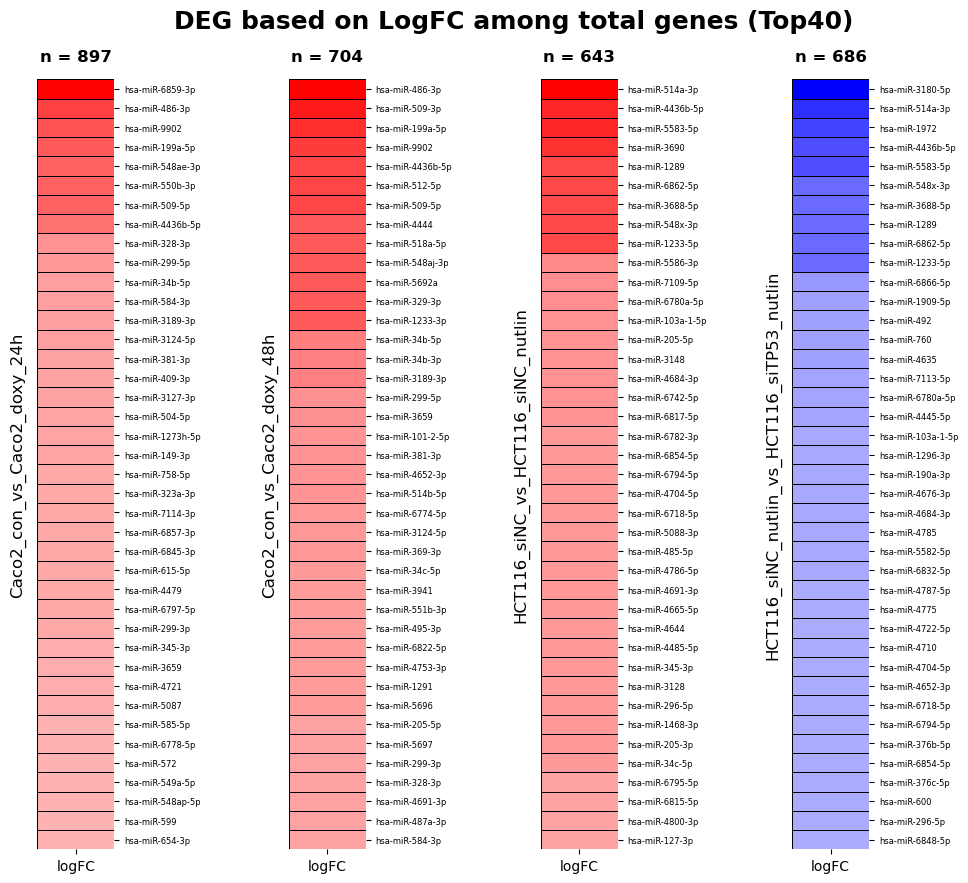

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

fig, axes = plt.subplots(1, len(files), figsize=(len(files) * 3, 10))
plt.subplots_adjust(left=0.22, right=0.98, wspace=0.6)
fig.suptitle("DEG based on LogFC among total genes (Top40)", fontsize=18, fontweight='bold', x=0.65, y=0.95)

for ax, (name, fname) in zip(axes, files):
    df = pd.read_csv(base + fname, index_col=0)

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.0]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.0]
        df = df.sort_values("logFC", ascending=False)

    count = len(df)

    logfc = df[["logFC"]].head(40)

    sns.heatmap(
        logfc,
        ax=ax,
        cmap="bwr",
        center=0,
        cbar=False,
        linewidths=0.5,
        linecolor="black"
    )

    ax.set_aspect(0.25)
    ax.yaxis.tick_right()
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)

    ax.text(
        -0.25, 0.5,
        name,
        rotation=90,
        va="center",
        ha="center",
        transform=ax.transAxes,
        fontsize=12
    )

    ax.text(
        0.5, 1.02,
        f"n = {count}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

plt.show()

In [3]:
import pandas as pd
import os

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
outdir = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/only_logFC>0.0/"
os.makedirs(outdir, exist_ok=True)

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

all_genes = []

for name, fname in files:
    df = pd.read_csv(os.path.join(base, fname), index_col=0)

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.0]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.0]
        df = df.sort_values("logFC", ascending=False)

    df_reset = df.reset_index()[["index", "logFC", "PValue"]]
    df_reset.rename(columns={"index": "Gene"}, inplace=True)
    df_reset["Comparison"] = name
    all_genes.append(df_reset)

all_genes_df = pd.concat(all_genes, axis=0)
all_genes_df.to_csv(os.path.join(outdir, "all_comparisons_gene_list.csv"), index=False)

In [4]:
#####################################
############ CEBPB G ################
#####################################

/tmp/ipykernel_3451639/2642313276.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  logfc_padded = pd.concat([logfc, pad_df])
/tmp/ipykernel_3451639/2642313276.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  logfc_padded = pd.concat([logfc, pad_df])
/tmp/ipykernel_3451639/2642313276.py:50: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result d

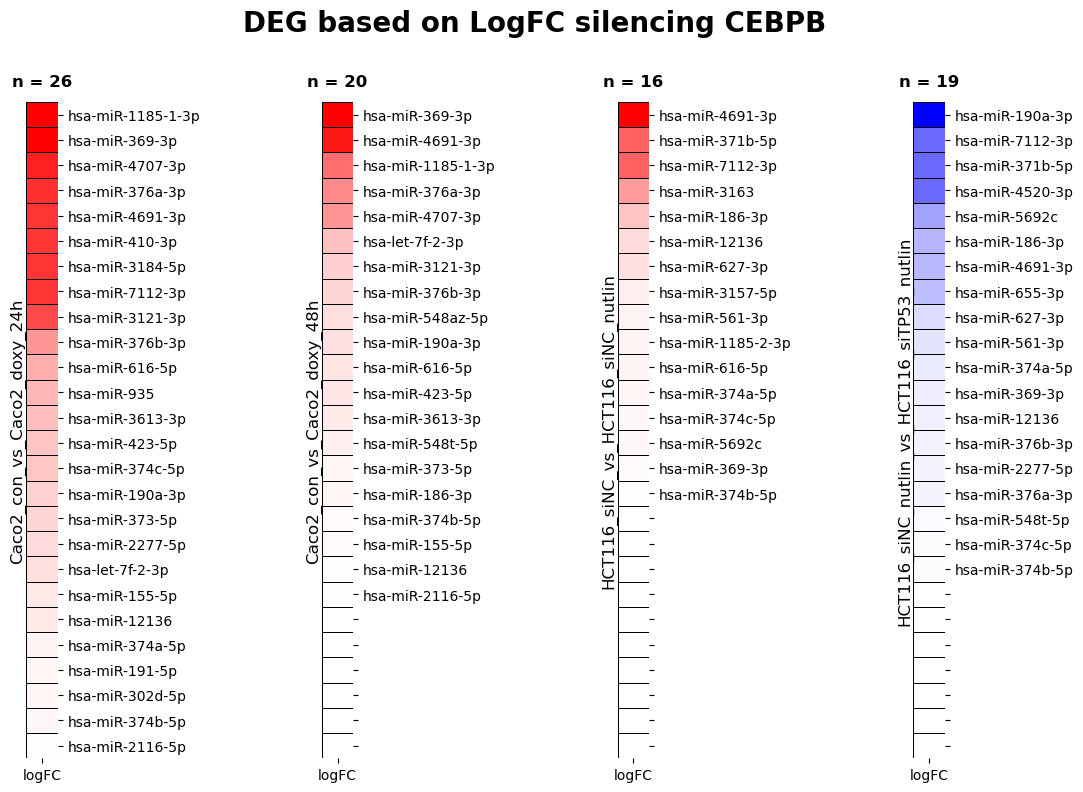

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.0]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.0]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        results.append((name, df))

max_rows = max(len(df) for _, df in results)
n = len(results)

fig, axes = plt.subplots(1, n, figsize=(n * 3, max_rows * 0.3 ))
plt.subplots_adjust(left=0.22, right=0.98, wspace=2)
if n == 1:
    axes = [axes]

fig.suptitle("DEG based on LogFC silencing CEBPB", fontsize=20, fontweight='bold', x=0.5, y=1.01)

for ax, (name, df) in zip(axes, results):
    count = len(df)
    logfc = df[["logFC"]]

    pad_rows = max_rows - count
    if pad_rows > 0:
        pad_df = pd.DataFrame(
            [[None] * len(logfc.columns)] * pad_rows,
            columns=logfc.columns,
            index=[""] * pad_rows
        )
        logfc_padded = pd.concat([logfc, pad_df])
    else:
        logfc_padded = logfc

    mask = logfc_padded.isnull()

    sns.heatmap(
        logfc_padded.astype(float),
        ax=ax,
        cmap="bwr",
        center=0,
        cbar=False,
        linewidths=0.5,
        linecolor="black",
        mask=mask
    )
    ax.set_aspect(0.8)
    ax.yaxis.tick_right()
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
    ax.text(-0.25, 0.5, name, rotation=90,
            va="center", ha="center",
            transform=ax.transAxes, fontsize=12)
    ax.text(0.5, 1.02, f"n = {count}",
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

plt.tight_layout()
plt.show()

In [10]:
import pandas as pd
import os

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
outdir = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/only_logFC>0.0/"

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

all_results = []

for name, fname in files:
    df = pd.read_csv(os.path.join(base, fname), index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.0]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.0]
        df = df.sort_values("logFC", ascending=False)

    if not df.empty:
        df_reset = df.reset_index().rename(columns={"index": "miRNA"})
        df_reset["Comparison"] = name
        all_results.append(df_reset)

if all_results:
    all_df = pd.concat(all_results, axis=0)
    all_df.to_csv(os.path.join(outdir, "all_CEBPB_miRNAs.csv"), index=False)

In [15]:
import pandas as pd

df = pd.read_csv("/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/only_logFC>0.0/all_CEBPB_miRNAs.csv")

tarbase_list = [
"hsa-miR-191-5p","hsa-miR-34a-5p","hsa-miR-423-5p","hsa-miR-16-5p","hsa-let-7d-5p",
"hsa-let-7i-5p","hsa-miR-17-5p","hsa-miR-29b-3p","hsa-miR-21-3p","hsa-miR-33b-5p",
"hsa-let-7c-5p","hsa-miR-29a-3p","hsa-miR-29c-3p","hsa-miR-92b-3p","hsa-let-7f-2-3p",
"hsa-miR-106a-5p","hsa-miR-148b-5p","hsa-miR-15a-5p","hsa-miR-210-3p","hsa-miR-19b-3p",
"hsa-miR-27b-3p","hsa-miR-33a-5p","hsa-miR-374b-5p","hsa-miR-93-5p","hsa-miR-98-5p",
"hsa-let-7a-5p","hsa-let-7e-5p","hsa-miR-100-5p","hsa-miR-155-5p","hsa-miR-181b-5p",
"hsa-miR-194-5p","hsa-miR-195-5p","hsa-miR-302c-3p","hsa-miR-374a-5p","hsa-miR-99b-3p",
"hsa-miR-139-5p","hsa-miR-15b-5p","hsa-miR-421","hsa-miR-423-3p","hsa-miR-424-5p",
"hsa-miR-625-5p","hsa-miR-671-5p","hsa-miR-92a-3p","hsa-let-7b-5p","hsa-let-7g-5p",
"hsa-miR-100-3p","hsa-miR-101-3p","hsa-miR-106b-5p","hsa-miR-107","hsa-miR-10b-5p",
"hsa-miR-1301-3p","hsa-miR-1-3p","hsa-miR-147b-3p","hsa-miR-148a-3p","hsa-miR-148b-3p",
"hsa-miR-182-5p","hsa-miR-203a-3p","hsa-miR-203b-5p","hsa-miR-20b-5p","hsa-miR-222-3p",
"hsa-miR-26a-5p","hsa-miR-27a-3p","hsa-miR-30d-5p","hsa-miR-455-5p","hsa-miR-484",
"hsa-miR-486-3p","hsa-miR-877-5p","hsa-miR-941","hsa-let-7f-5p","hsa-miR-103a-1-5p",
"hsa-miR-103a-3p","hsa-miR-124-3p","hsa-miR-1246","hsa-miR-1266-5p","hsa-miR-1277-5p",
"hsa-miR-128-1-5p","hsa-miR-1307-3p","hsa-miR-138-5p","hsa-miR-145-3p","hsa-miR-147a",
"hsa-miR-151a-5p","hsa-miR-152-3p","hsa-miR-18a-3p","hsa-miR-18a-5p","hsa-miR-190b-5p",
"hsa-miR-192-5p","hsa-miR-193b-3p","hsa-miR-19a-3p","hsa-miR-200a-5p","hsa-miR-205-5p",
"hsa-miR-20a-5p","hsa-miR-218-5p","hsa-miR-22-5p","hsa-miR-23b-3p","hsa-miR-25-5p",
"hsa-miR-27a-5p","hsa-miR-302a-3p","hsa-miR-30a-5p","hsa-miR-30b-3p","hsa-miR-30b-5p",
"hsa-miR-30e-3p","hsa-miR-3184-5p","hsa-miR-324-3p","hsa-miR-32-5p","hsa-miR-331-3p",
"hsa-miR-33b-3p","hsa-miR-342-5p","hsa-miR-34c-5p","hsa-miR-3652","hsa-miR-372-3p",
"hsa-miR-378a-3p","hsa-miR-425-3p","hsa-miR-449a","hsa-miR-449c-5p","hsa-miR-450b-5p",
"hsa-miR-454-5p","hsa-miR-4664-3p","hsa-miR-516b-5p","hsa-miR-574-5p","hsa-miR-576-3p",
"hsa-miR-629-5p","hsa-miR-652-3p","hsa-miR-744-5p","hsa-miR-96-5p","hsa-miR-99a-3p",
"hsa-miR-99a-5p","kshv-miR-K12-6-5p"
]

mirtarbase_list = [
"hsa-miR-423-5p","hsa-let-7c-5p","hsa-miR-34a-5p","hsa-miR-191-5p","hsa-miR-155-5p",
"hsa-miR-374a-5p","hsa-miR-663a","hsa-miR-373-5p","hsa-miR-561-3p","hsa-miR-616-5p",
"hsa-miR-22-5p","hsa-miR-371a-5p","hsa-miR-513c-5p","hsa-miR-548n","hsa-miR-2116-5p",
"hsa-miR-548t-5p","hsa-miR-514b-5p","hsa-miR-4255","hsa-miR-3613-3p","hsa-miR-4477a",
"hsa-miR-4677-5p","hsa-miR-371b-5p","hsa-miR-548az-5p","hsa-miR-372-5p","hsa-miR-155-3p",
"hsa-miR-421"
]

df["Source"] = "None"
df.loc[df["miRNA"].isin(tarbase_list), "Source"] = "TarBase"
df.loc[df["miRNA"].isin(mirtarbase_list), "Source"] = "MirTarBase"
df.loc[
    df["miRNA"].isin(tarbase_list) & df["miRNA"].isin(mirtarbase_list),
    "Source"
] = "Both"

result = df[df["Source"] != "None"]

result.to_csv("/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/only_logFC>0.0/CEBPB_miRNA_overlap.csv", index=False)

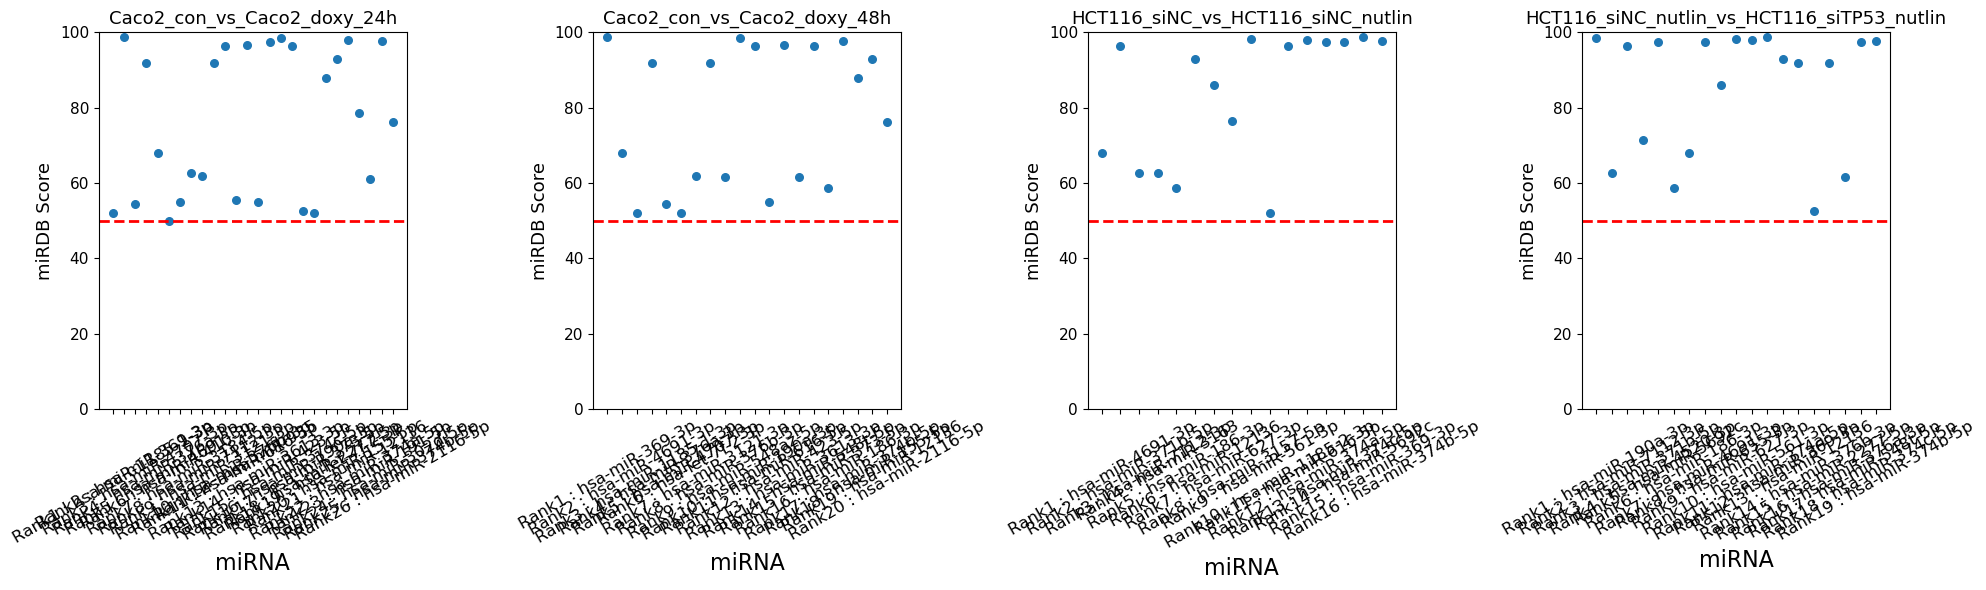

In [64]:
import pandas as pd
import matplotlib.pyplot as plt

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df.merge(
        mirdb[["miRNA", "Score"]],
        left_index=True,
        right_on="miRNA",
        how="inner"
    )
    df = df.set_index("miRNA")
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.0]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.0]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        df["rank"] = range(1, len(df) + 1)
        results.append((name, df))

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(n * 5, 6))
plt.subplots_adjust(wspace=0.6)
if n == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, results):
    ax.scatter(df["rank"], df["Score"], s=30)
    x_labels = [f"Rank{r} : {mirna}" for r, mirna in zip(df["rank"], df.index.tolist())]
    ax.set_xticks(df["rank"])
    ax.set_xticklabels(x_labels, rotation=30, fontsize=12)
    ax.set_ylim(0, 100)
    ax.axhline(y=50, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel("miRNA", fontsize=16)
    ax.set_ylabel("miRDB Score", fontsize=13)
    ax.set_title(name, fontsize=13)
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

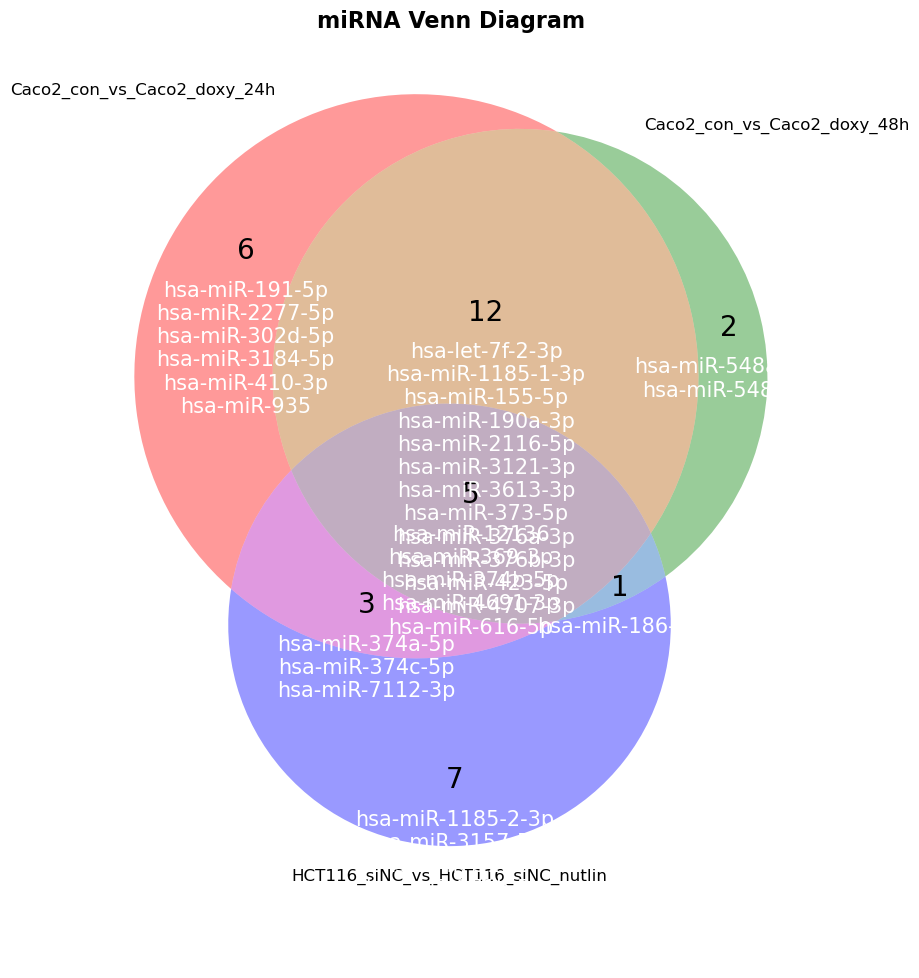

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df.merge(
        mirdb[["miRNA", "Score"]],
        left_index=True,
        right_on="miRNA",
        how="inner"
    )
    df = df.set_index("miRNA")
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.0]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.0]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        df["rank"] = range(1, len(df) + 1)
        results.append((name, df))

sets = [set(df.index.tolist()) for _, df in results]
full_labels = [name for name, _ in results]

s0, s1, s2 = sets[0], sets[1], sets[2]

only0  = s0 - s1 - s2
only1  = s1 - s0 - s2
only2  = s2 - s0 - s1
only01 = (s0 & s1) - s2
only02 = (s0 & s2) - s1
only12 = (s1 & s2) - s0
all3   = s0 & s1 & s2

region_map = {
    '100': only0,
    '010': only1,
    '001': only2,
    '110': only01,
    '101': only02,
    '011': only12,
    '111': all3,
}

fig, ax = plt.subplots(figsize=(14, 10))

v = venn3(
    subsets=(s0, s1, s2),
    set_labels=(full_labels[0], full_labels[1], full_labels[2]),
    ax=ax
)

for label in v.set_labels:
    if label:
        label.set_fontsize(12)

for region_id, mirna_set in region_map.items():
    label = v.get_label_by_id(region_id)
    if label:
        if mirna_set:
            count = len(mirna_set)
            names = "\n".join(sorted(mirna_set))
            x, y = label.get_position()
            label.set_text(str(count))
            label.set_fontsize(20)
            ax.text(x, y - 0.05, names,
                    ha='center', va='top',
                    fontsize=15, color='white',
                    transform=ax.transData)
        else:
            label.set_text("0")
            label.set_fontsize(14)

ax.set_title("miRNA Venn Diagram", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

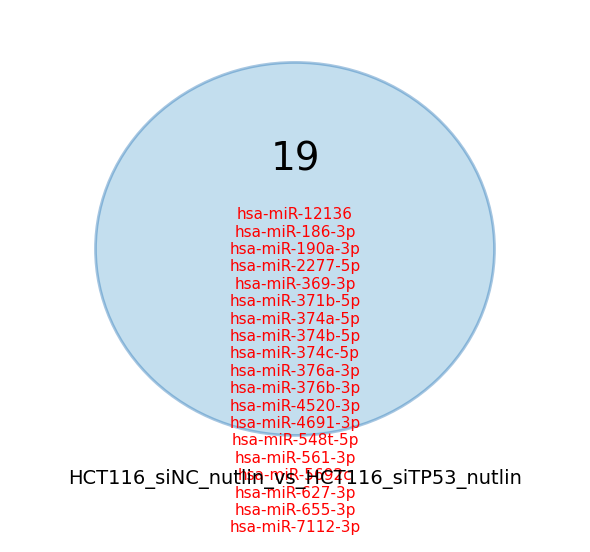

In [71]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df.merge(mirdb[["miRNA", "Score"]], left_index=True, right_on="miRNA", how="inner")
    df = df.set_index("miRNA")
    df = df[df["logFC"] < -0.0]
    df = df.sort_values("logFC", ascending=True)
    if not df.empty:
        df["rank"] = range(1, len(df) + 1)
        results.append((name, df))

name, df = results[0]
mirnas = sorted(df.index.tolist())
n = len(mirnas)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

circle = mpatches.Circle((0.5, 0.55), 0.35,
                          facecolor='#6baed6', alpha=0.4,
                          edgecolor='#2171b5', linewidth=2)
ax.add_patch(circle)

ax.text(0.5, 0.72, str(n), transform=ax.transAxes,
        va='center', ha='center', fontsize=28, color='black')

mirna_text = "\n".join(mirnas)
ax.text(0.5, 0.63, mirna_text, transform=ax.transAxes,
        va='top', ha='center', fontsize=11, color='red')

ax.text(0.5, 0.12, name, transform=ax.transAxes,
        va='center', ha='center', fontsize=14, color='black')

plt.tight_layout()
plt.show()

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

<Figure size 1000x600 with 0 Axes>

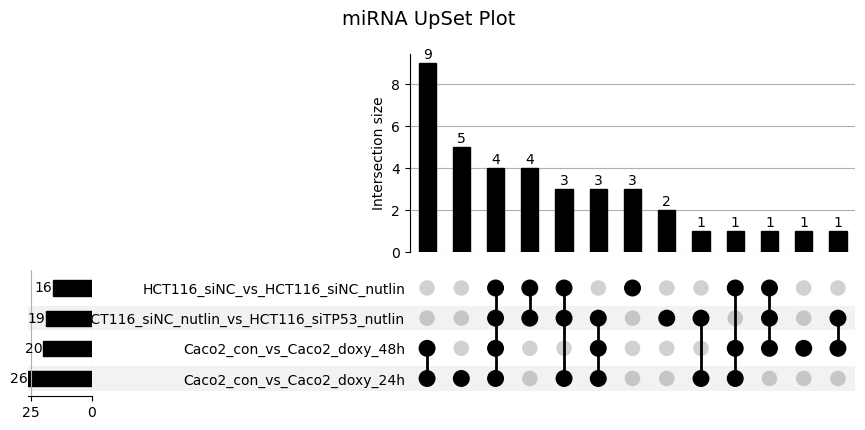

In [74]:
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df.merge(
        mirdb[["miRNA", "Score"]],
        left_index=True,
        right_on="miRNA",
        how="inner"
    )
    df = df.set_index("miRNA")
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < 0]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        results.append((name, df))

contents = {
    name: set(df.index.tolist())
    for name, df in results
}

data = from_contents(contents)

plt.figure(figsize=(10,6))
UpSet(data, show_counts=True, sort_by='cardinality').plot()
plt.suptitle("miRNA UpSet Plot", fontsize=14)
plt.show()

In [75]:
common_all = set.intersection(*contents.values())
print(f"Total: {len(common_all)}")
print("\n".join(sorted(common_all)))

Total: 4
hsa-miR-12136
hsa-miR-369-3p
hsa-miR-374b-5p
hsa-miR-4691-3p


# Heatmap (P val, logFC > 0.5)

In [84]:
#####################################
############ All DEG ################
#####################################

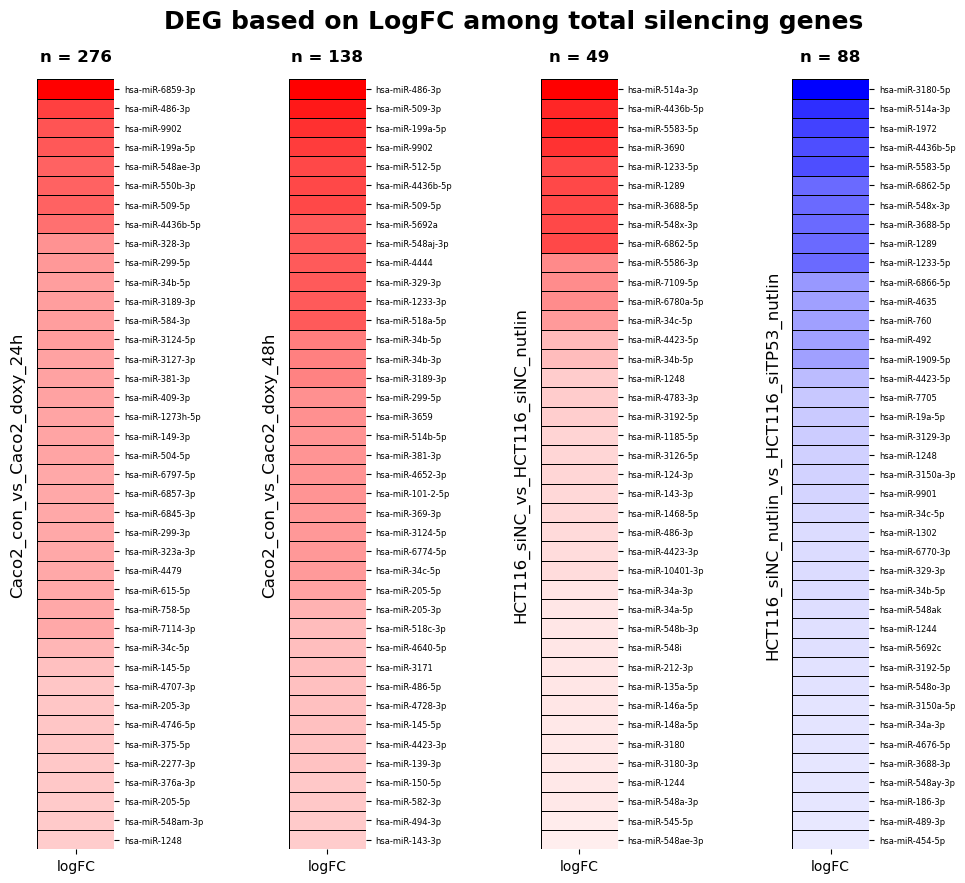

In [81]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

fig, axes = plt.subplots(1, len(files), figsize=(len(files) * 3, 10))
plt.subplots_adjust(left=0.22, right=0.98, wspace=0.6)
fig.suptitle("DEG based on LogFC among total silencing genes", fontsize=18, fontweight='bold', x=0.65, y=0.95)

for ax, (name, fname) in zip(axes, files):
    df = pd.read_csv(base + fname, index_col=0)

    df = df[(df["PValue"] < 0.05)]

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.5]
        df = df.sort_values("logFC", ascending=False)

    count = len(df)

    logfc = df[["logFC"]].head(40)

    sns.heatmap(
        logfc,
        ax=ax,
        cmap="bwr",
        center=0,
        cbar=False,
        linewidths=0.5,
        linecolor="black"
    )

    ax.set_aspect(0.25)
    ax.yaxis.tick_right()
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)

    ax.text(
        -0.25, 0.5,
        name,
        rotation=90,
        va="center",
        ha="center",
        transform=ax.transAxes,
        fontsize=12
    )

    ax.text(
        0.5, 1.02,
        f"n = {count}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

plt.show()

In [83]:
import pandas as pd
import os

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
outdir = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/Pval_logFC>0.5/"
os.makedirs(outdir, exist_ok=True)

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

all_genes = []

for name, fname in files:
    df = pd.read_csv(os.path.join(base, fname), index_col=0)
    df = df[df["PValue"] < 0.05]

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.5]
        df = df.sort_values("logFC", ascending=False)

    df_reset = df.reset_index()[["index", "logFC", "PValue"]]
    df_reset.rename(columns={"index": "Gene"}, inplace=True)
    df_reset["Comparison"] = name
    all_genes.append(df_reset)

all_genes_df = pd.concat(all_genes, axis=0)
all_genes_df.to_csv(os.path.join(outdir, "all_comparisons_gene_list.csv"), index=False)

In [85]:
#####################################
############ CEBPB G ################
#####################################

/tmp/ipykernel_3407611/1241854033.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  logfc_padded = pd.concat([logfc, pad_df])
/tmp/ipykernel_3407611/1241854033.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  logfc_padded = pd.concat([logfc, pad_df])
/tmp/ipykernel_3407611/1241854033.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result d

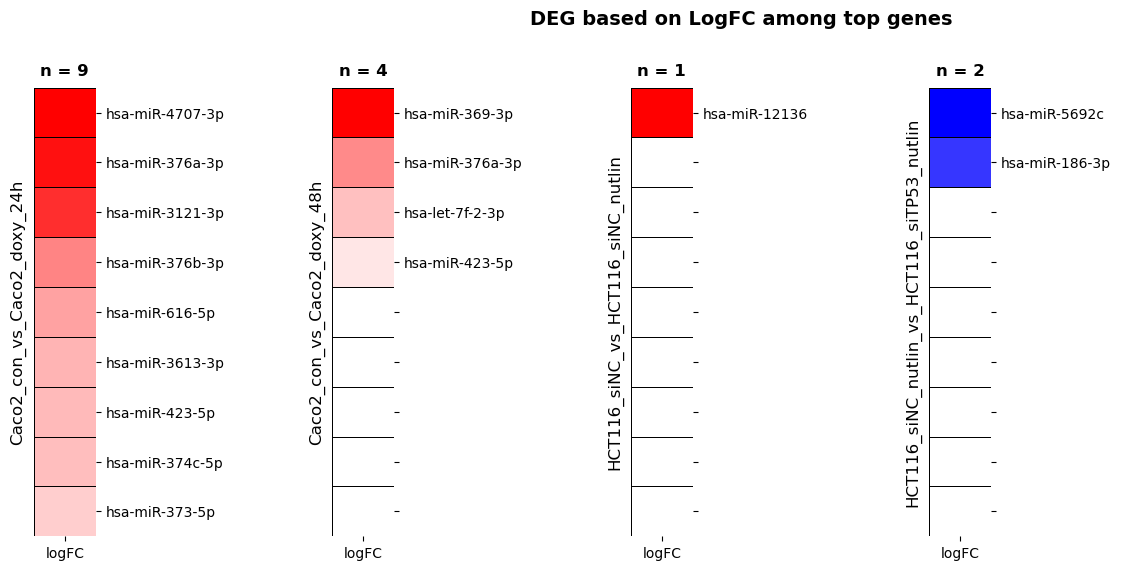

In [86]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df = df[df["PValue"] < 0.05]
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.5]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        results.append((name, df))

max_rows = max(len(df) for _, df in results)
n = len(results)

fig, axes = plt.subplots(1, n, figsize=(n * 3, max_rows * 0.4 + 2))
plt.subplots_adjust(left=0.22, right=0.98, wspace=2)
if n == 1:
    axes = [axes]

fig.suptitle("DEG based on LogFC among top genes", fontsize=14, fontweight='bold', x=0.65, y=1.01)

for ax, (name, df) in zip(axes, results):
    count = len(df)
    logfc = df[["logFC"]]

    pad_rows = max_rows - count
    if pad_rows > 0:
        pad_df = pd.DataFrame(
            [[None] * len(logfc.columns)] * pad_rows,
            columns=logfc.columns,
            index=[""] * pad_rows
        )
        logfc_padded = pd.concat([logfc, pad_df])
    else:
        logfc_padded = logfc

    mask = logfc_padded.isnull()

    sns.heatmap(
        logfc_padded.astype(float),
        ax=ax,
        cmap="bwr",
        center=0,
        cbar=False,
        linewidths=0.5,
        linecolor="black",
        mask=mask
    )
    ax.set_aspect(0.8)
    ax.yaxis.tick_right()
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
    ax.text(-0.25, 0.5, name, rotation=90,
            va="center", ha="center",
            transform=ax.transAxes, fontsize=12)
    ax.text(0.5, 1.02, f"n = {count}",
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

plt.tight_layout()
plt.show()

In [90]:
import pandas as pd
import os

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
outdir = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/Pval_logFC>0.5/"

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

all_results = []

for name, fname in files:
    df = pd.read_csv(os.path.join(base, fname), index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df = df[df["PValue"] < 0.05]

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.5]
        df = df.sort_values("logFC", ascending=False)

    if not df.empty:
        df_reset = df.reset_index().rename(columns={"index": "miRNA"})
        df_reset["Comparison"] = name
        all_results.append(df_reset)

if all_results:
    all_df = pd.concat(all_results, axis=0)
    all_df.to_csv(os.path.join(outdir, "all_CEBPB_miRNAs.csv"), index=False)

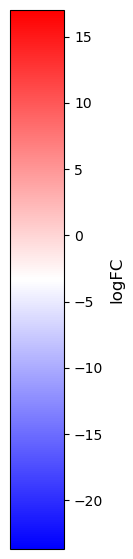

In [79]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"

files = [
    "caco2_con_vs_caco2_doxy_24h.csv",
    "caco2_con_vs_caco2_doxy_48h.csv",
    "hct116_sinc_vs_hct116_sinc_nutlin.csv",
    "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv"
]

all_logfc = []
for f in files:
    df = pd.read_csv(base + f, index_col=0)
    all_logfc.extend(df["logFC"].values)

vmin = min(all_logfc)
vmax = max(all_logfc)

%matplotlib inline
fig, ax = plt.subplots(figsize=(0.7, 7))

norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cbar = mpl.colorbar.ColorbarBase(
    ax,
    cmap="bwr",
    norm=norm,
    orientation="vertical"
)
cbar.set_label("logFC", fontsize=12)

plt.show()

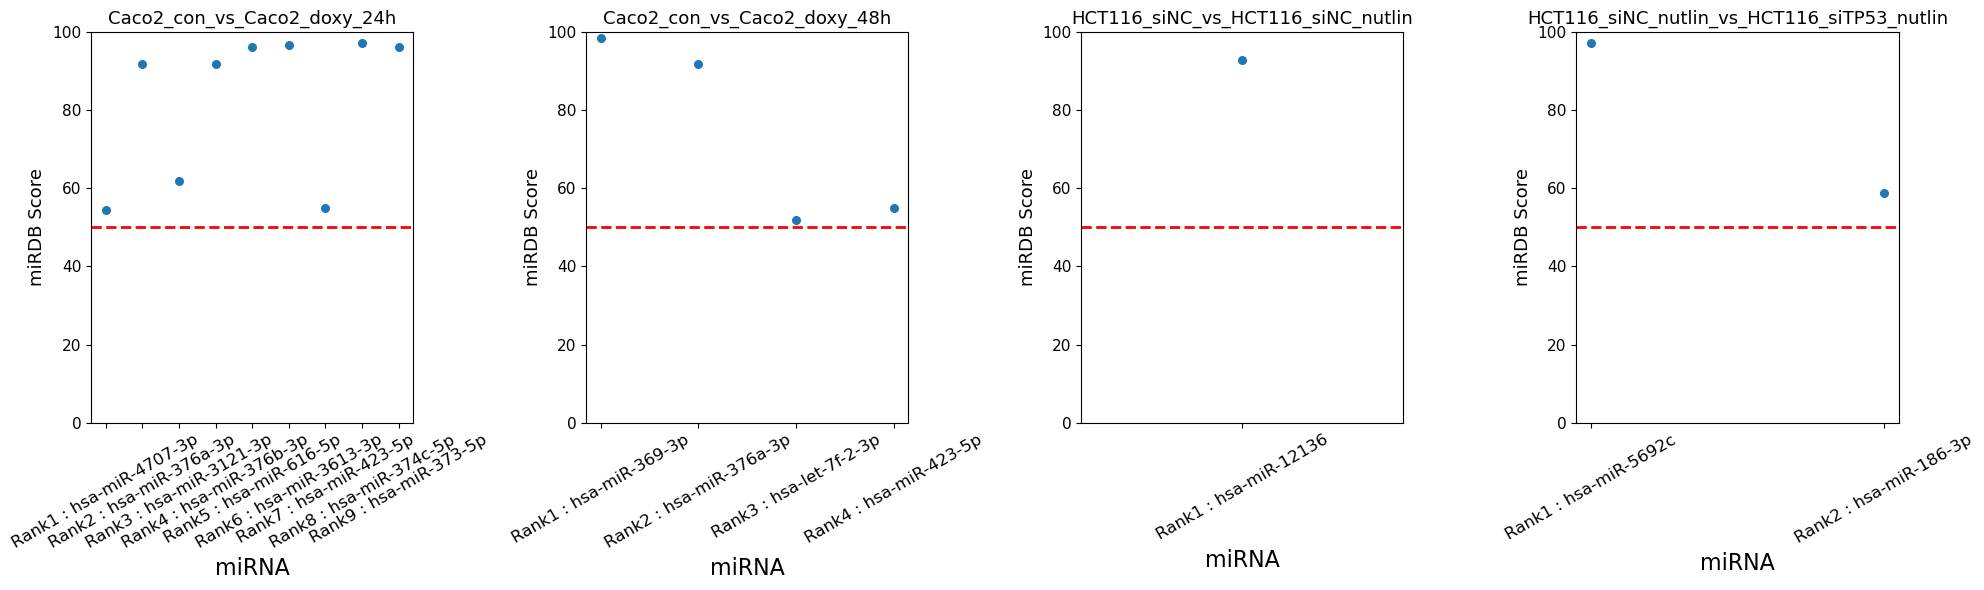

In [34]:
import pandas as pd
import matplotlib.pyplot as plt

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[(df["PValue"] < 0.05)]
    df = df.merge(
        mirdb[["miRNA", "Score"]],
        left_index=True,
        right_on="miRNA",
        how="inner"
    )
    df = df.set_index("miRNA")
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.5]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        df["rank"] = range(1, len(df) + 1)
        results.append((name, df))

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(n * 5, 6))
plt.subplots_adjust(wspace=0.6)
if n == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, results):
    ax.scatter(df["rank"], df["Score"], s=30)
    x_labels = [f"Rank{r} : {mirna}" for r, mirna in zip(df["rank"], df.index.tolist())]
    ax.set_xticks(df["rank"])
    ax.set_xticklabels(x_labels, rotation=30, fontsize=12)
    ax.set_ylim(0, 100)
    ax.axhline(y=50, color='red', linestyle='--', linewidth=2)
    ax.set_xlabel("miRNA", fontsize=16)
    ax.set_ylabel("miRDB Score", fontsize=13)
    ax.set_title(name, fontsize=13)
    ax.tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

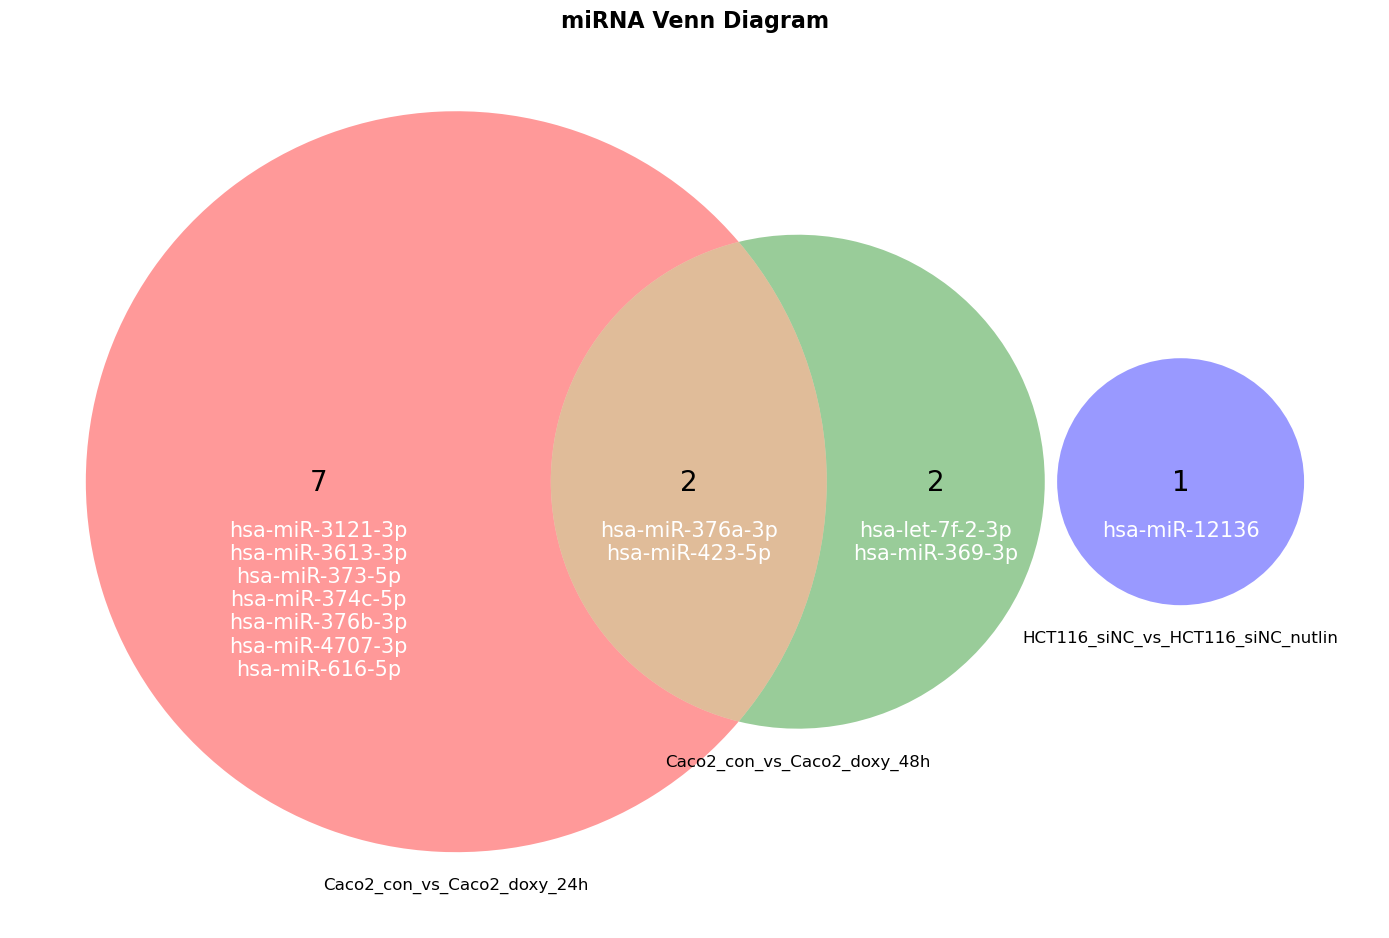

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[(df["PValue"] < 0.05) ]
    df = df.merge(
        mirdb[["miRNA", "Score"]],
        left_index=True,
        right_on="miRNA",
        how="inner"
    )
    df = df.set_index("miRNA")
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.5]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        df["rank"] = range(1, len(df) + 1)
        results.append((name, df))

sets = [set(df.index.tolist()) for _, df in results]
full_labels = [name for name, _ in results]

s0, s1, s2 = sets[0], sets[1], sets[2]

only0  = s0 - s1 - s2
only1  = s1 - s0 - s2
only2  = s2 - s0 - s1
only01 = (s0 & s1) - s2
only02 = (s0 & s2) - s1
only12 = (s1 & s2) - s0
all3   = s0 & s1 & s2

region_map = {
    '100': only0,
    '010': only1,
    '001': only2,
    '110': only01,
    '101': only02,
    '011': only12,
    '111': all3,
}

fig, ax = plt.subplots(figsize=(14, 10))

v = venn3(
    subsets=(s0, s1, s2),
    set_labels=(full_labels[0], full_labels[1], full_labels[2]),
    ax=ax
)

for label in v.set_labels:
    if label:
        label.set_fontsize(12)

for region_id, mirna_set in region_map.items():
    label = v.get_label_by_id(region_id)
    if label:
        if mirna_set:
            count = len(mirna_set)
            names = "\n".join(sorted(mirna_set))
            x, y = label.get_position()
            label.set_text(str(count))
            label.set_fontsize(20)
            ax.text(x, y - 0.05, names,
                    ha='center', va='top',
                    fontsize=15, color='white',
                    transform=ax.transData)
        else:
            label.set_text("0")
            label.set_fontsize(14)

ax.set_title("miRNA Venn Diagram", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

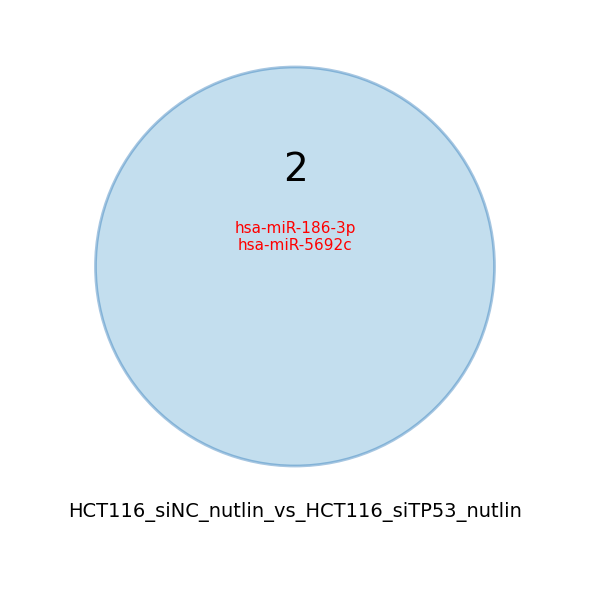

In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df["PValue"] < 0.05]
    df = df.merge(mirdb[["miRNA", "Score"]], left_index=True, right_on="miRNA", how="inner")
    df = df.set_index("miRNA")
    df = df[df["logFC"] < -0.5]
    df = df.sort_values("logFC", ascending=True)
    if not df.empty:
        df["rank"] = range(1, len(df) + 1)
        results.append((name, df))

name, df = results[0]
mirnas = sorted(df.index.tolist())
n = len(mirnas)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

circle = mpatches.Circle((0.5, 0.55), 0.35,
                          facecolor='#6baed6', alpha=0.4,
                          edgecolor='#2171b5', linewidth=2)
ax.add_patch(circle)

ax.text(0.5, 0.72, str(n), transform=ax.transAxes,
        va='center', ha='center', fontsize=28, color='black')

mirna_text = "\n".join(mirnas)
ax.text(0.5, 0.63, mirna_text, transform=ax.transAxes,
        va='top', ha='center', fontsize=11, color='red')

ax.text(0.5, 0.12, name, transform=ax.transAxes,
        va='center', ha='center', fontsize=14, color='black')

plt.tight_layout()
plt.show()

/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/home/Data_Drive_8TB/kykim/.conda/envs/kykim/lib/python3.9/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original objec

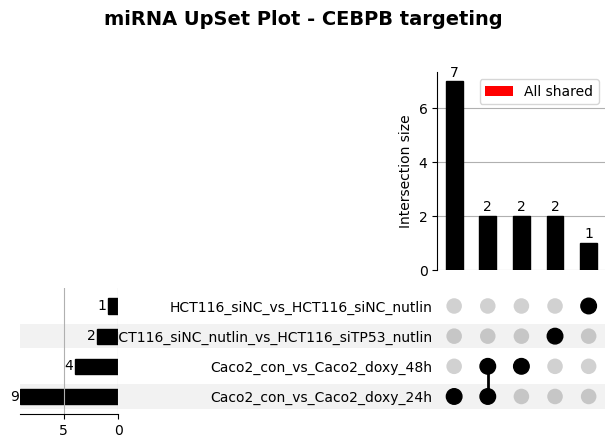

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_contents

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mirdb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df["PValue"] < 0.05]
    df = df.merge(
        mirdb[["miRNA", "Score"]],
        left_index=True,
        right_on="miRNA",
        how="inner"
    )
    df = df.set_index("miRNA")
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.5]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        results.append((name, df))

contents = {name: set(df.index.tolist()) for name, df in results}

data = from_contents(contents)

upset = UpSet(
    data,
    subset_size="count",
    show_counts=True,
    totals_plot_elements=3,
    sort_by="cardinality"
)

upset.style_subsets(
    present=list(contents.keys()),
    facecolor="red",
    label="All shared"
)

fig = plt.figure(figsize=(16, 8))
upset.plot(fig)

plt.suptitle("miRNA UpSet Plot - CEBPB targeting", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# Heatmap (P val, logFC > 0.25)

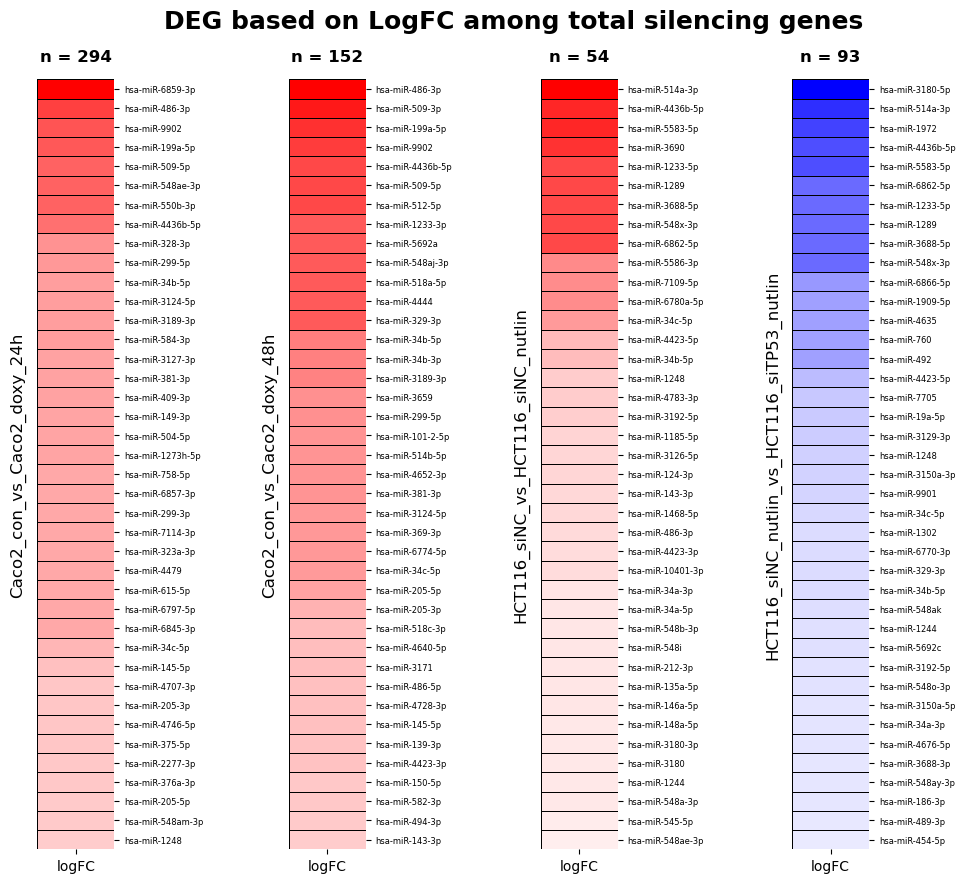

In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

fig, axes = plt.subplots(1, len(files), figsize=(len(files) * 3, 10))
plt.subplots_adjust(left=0.22, right=0.98, wspace=0.6)
fig.suptitle("DEG based on LogFC among total silencing genes", fontsize=18, fontweight='bold', x=0.65, y=0.95)

for ax, (name, fname) in zip(axes, files):
    df = pd.read_csv(base + fname, index_col=0)

    df = df[(df["PValue"] < 0.05)]

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.25]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.25]
        df = df.sort_values("logFC", ascending=False)

    count = len(df)

    logfc = df[["logFC"]].head(40)

    sns.heatmap(
        logfc,
        ax=ax,
        cmap="bwr",
        center=0,
        cbar=False,
        linewidths=0.5,
        linecolor="black"
    )

    ax.set_aspect(0.25)
    ax.yaxis.tick_right()
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=6, rotation=0)

    ax.text(
        -0.25, 0.5,
        name,
        rotation=90,
        va="center",
        ha="center",
        transform=ax.transAxes,
        fontsize=12
    )

    ax.text(
        0.5, 1.02,
        f"n = {count}",
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

plt.show()

In [92]:
import pandas as pd
import os

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
outdir = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/Pval_logFC>0.25/"
os.makedirs(outdir, exist_ok=True)

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

all_genes = []

for name, fname in files:
    df = pd.read_csv(os.path.join(base, fname), index_col=0)
    df = df[df["PValue"] < 0.05]

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.25]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.25]
        df = df.sort_values("logFC", ascending=False)

    df_reset = df.reset_index()[["index", "logFC", "PValue"]]
    df_reset.rename(columns={"index": "Gene"}, inplace=True)
    df_reset["Comparison"] = name
    all_genes.append(df_reset)

all_genes_df = pd.concat(all_genes, axis=0)
all_genes_df.to_csv(os.path.join(outdir, "all_comparisons_gene_list.csv"), index=False)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

results = []
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df = df[df["PValue"] < 0.05]
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.25]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.25]
        df = df.sort_values("logFC", ascending=False)
    if not df.empty:
        results.append((name, df))

max_rows = max(len(df) for _, df in results)
n = len(results)

fig, axes = plt.subplots(1, n, figsize=(n * 3, max_rows * 0.4 + 2))
plt.subplots_adjust(left=0.22, right=0.98, wspace=2)
if n == 1:
    axes = [axes]

fig.suptitle("DEG based on LogFC among top genes", fontsize=14, fontweight='bold', x=0.65, y=1.01)

for ax, (name, df) in zip(axes, results):
    count = len(df)
    logfc = df[["logFC"]]

    pad_rows = max_rows - count
    if pad_rows > 0:
        pad_df = pd.DataFrame(
            [[None] * len(logfc.columns)] * pad_rows,
            columns=logfc.columns,
            index=[""] * pad_rows
        )
        logfc_padded = pd.concat([logfc, pad_df])
    else:
        logfc_padded = logfc

    mask = logfc_padded.isnull()

    sns.heatmap(
        logfc_padded.astype(float),
        ax=ax,
        cmap="bwr",
        center=0,
        cbar=False,
        linewidths=0.5,
        linecolor="black",
        mask=mask
    )
    ax.set_aspect(0.8)
    ax.yaxis.tick_right()
    ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
    ax.text(-0.25, 0.5, name, rotation=90,
            va="center", ha="center",
            transform=ax.transAxes, fontsize=12)
    ax.text(0.5, 1.02, f"n = {count}",
            transform=ax.transAxes,
            ha="center", va="bottom",
            fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv'

In [94]:
import pandas as pd
import os

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
outdir = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/Pval_logFC>0.25/"

files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

all_results = []

for name, fname in files:
    df = pd.read_csv(os.path.join(base, fname), index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df = df[df["PValue"] < 0.05]

    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.25]
        df = df.sort_values("logFC", ascending=True)
    else:
        df = df[df["logFC"] > 0.25]
        df = df.sort_values("logFC", ascending=False)

    if not df.empty:
        df_reset = df.reset_index().rename(columns={"index": "miRNA"})
        df_reset["Comparison"] = name
        all_results.append(df_reset)

if all_results:
    all_df = pd.concat(all_results, axis=0)
    all_df.to_csv(os.path.join(outdir, "all_CEBPB_miRNAs.csv"), index=False)

# Volcano plot

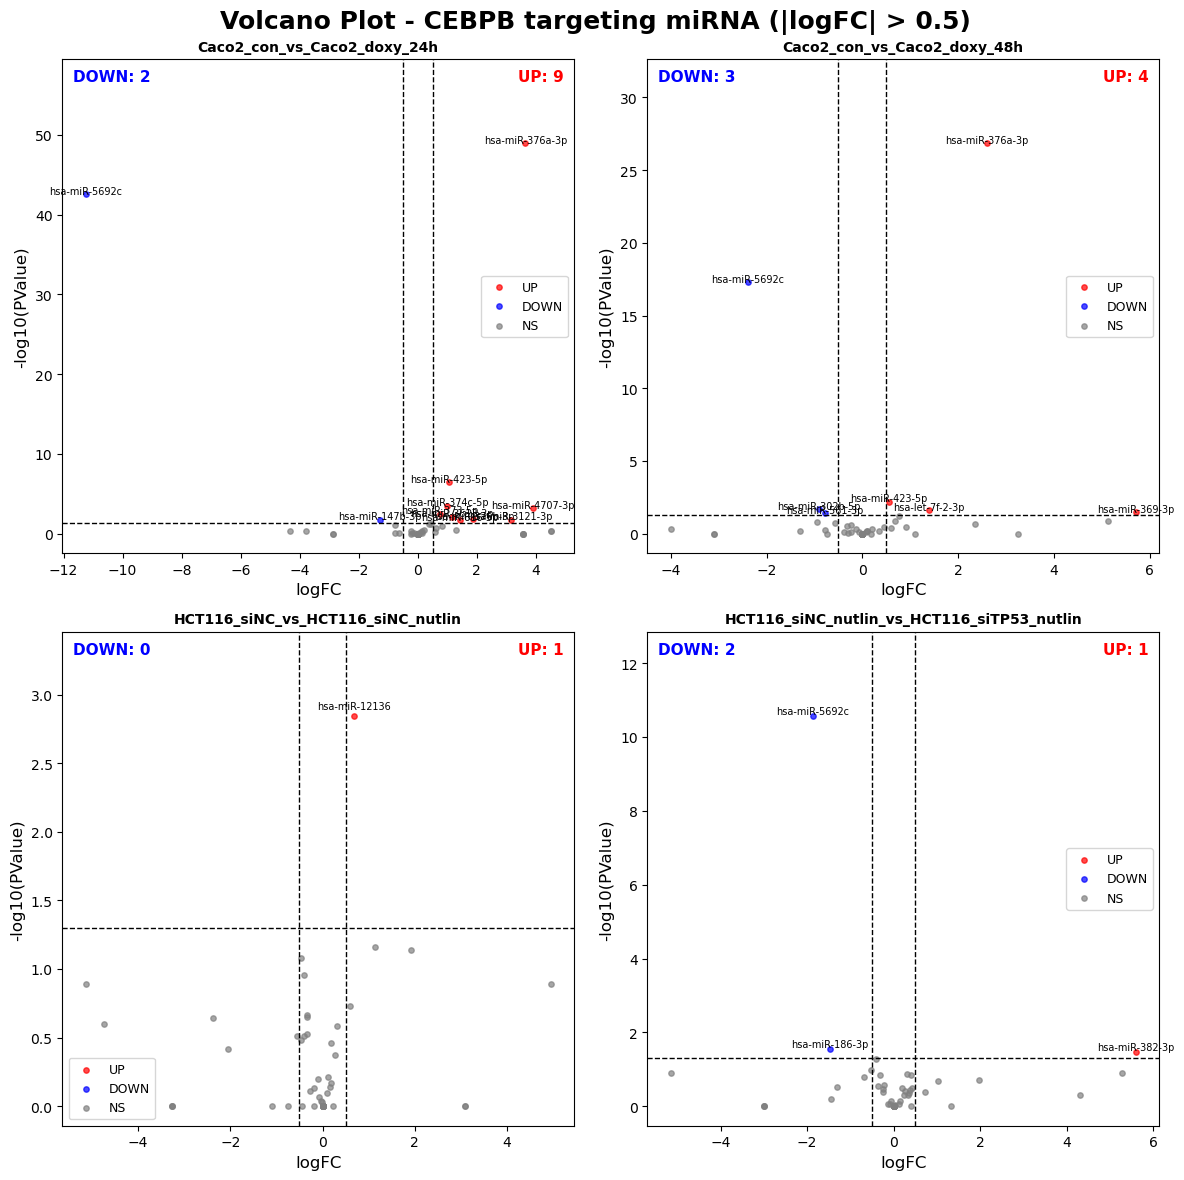

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
plt.subplots_adjust(wspace=0.4, hspace=0.4)
axes = axes.flatten()

for ax, (name, fname) in zip(axes, files):
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df["-log10P"] = -np.log10(df["PValue"])

    def classify(row):
        if row["PValue"] < 0.05 and row["logFC"] > 0.5:
            return "UP"
        elif row["PValue"] < 0.05 and row["logFC"] < -0.5:
            return "DOWN"
        else:
            return "NS"

    df["group"] = df.apply(classify, axis=1)

    colors = {"UP": "red", "DOWN": "blue", "NS": "gray"}
    for grp, color in colors.items():
        sub = df[df["group"] == grp]
        ax.scatter(sub["logFC"], sub["-log10P"], c=color, s=15, alpha=0.7, label=grp)

    ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.axvline(-0.5, color="black", linestyle="--", linewidth=1)

    up_n = (df["group"] == "UP").sum()
    down_n = (df["group"] == "DOWN").sum()

    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    ax.set_ylim(ymin, ymax + yrange * 0.15)

    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("logFC", fontsize=12)
    ax.set_ylabel("-log10(PValue)", fontsize=12)
    ax.legend(fontsize=9)

    ax.text(0.98, 0.98, f"UP: {up_n}", transform=ax.transAxes,
            ha="right", va="top", fontsize=11, color="red", fontweight="bold")
    ax.text(0.02, 0.98, f"DOWN: {down_n}", transform=ax.transAxes,
            ha="left", va="top", fontsize=11, color="blue", fontweight="bold")

    for mirna, row in df[df["group"] != "NS"].iterrows():
        ax.text(row["logFC"], row["-log10P"] + 0.05, mirna,
                fontsize=7, ha="center", color="black")

plt.suptitle("Volcano Plot - CEBPB targeting miRNA (|logFC| > 0.5)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

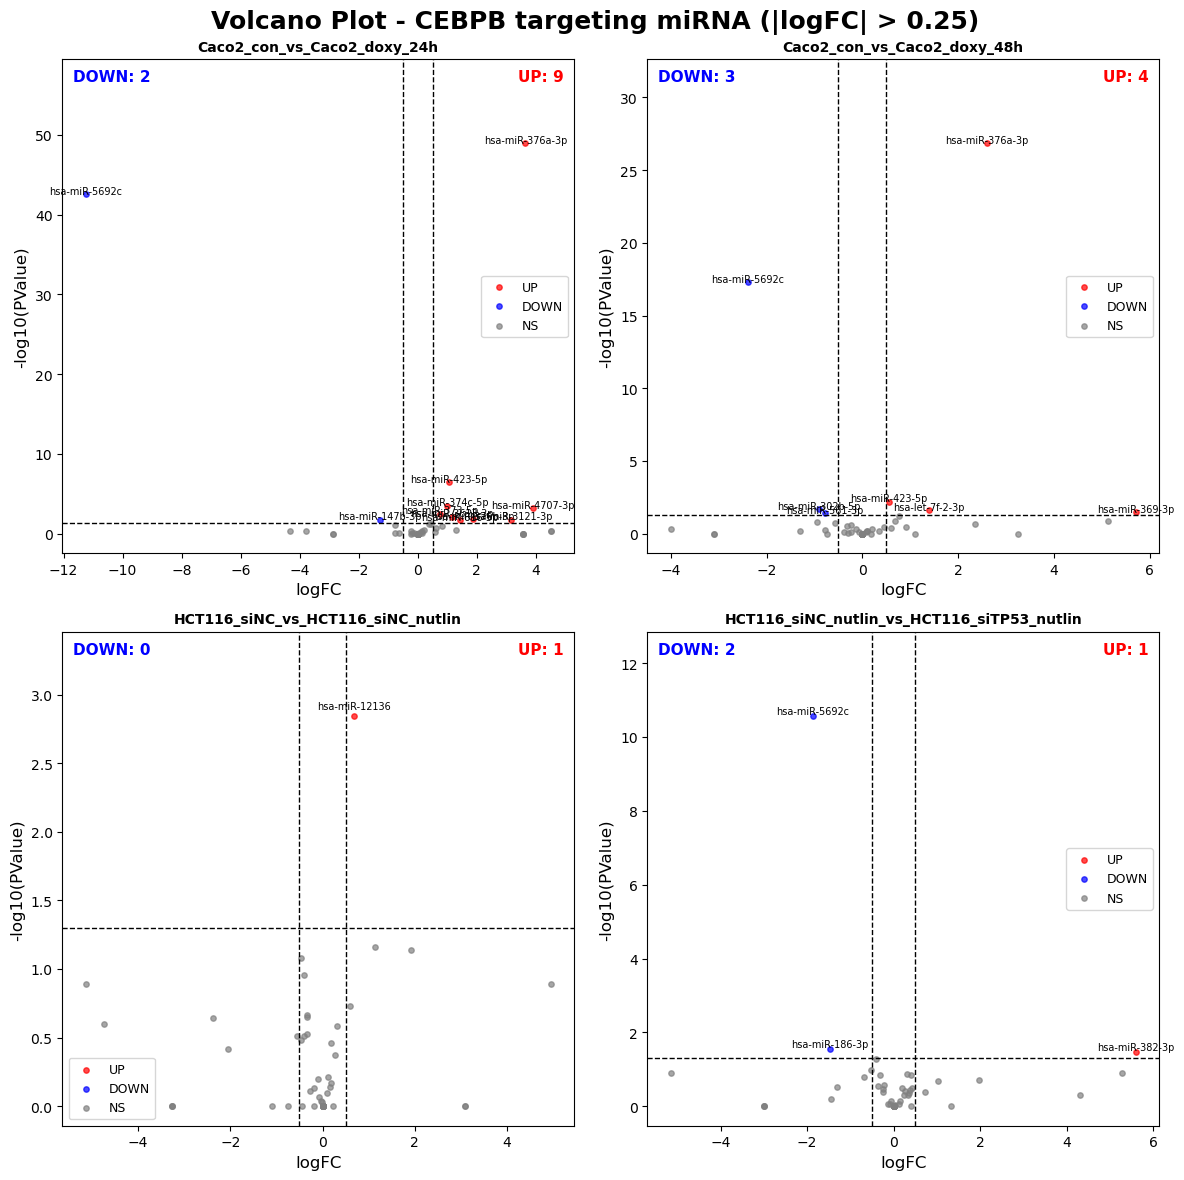

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
plt.subplots_adjust(wspace=0.4, hspace=0.4)
axes = axes.flatten()

for ax, (name, fname) in zip(axes, files):
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df["-log10P"] = -np.log10(df["PValue"])

    def classify(row):
        if row["PValue"] < 0.05 and row["logFC"] > 0.25:
            return "UP"
        elif row["PValue"] < 0.05 and row["logFC"] < -0.25:
            return "DOWN"
        else:
            return "NS"

    df["group"] = df.apply(classify, axis=1)

    colors = {"UP": "red", "DOWN": "blue", "NS": "gray"}
    for grp, color in colors.items():
        sub = df[df["group"] == grp]
        ax.scatter(sub["logFC"], sub["-log10P"], c=color, s=15, alpha=0.7, label=grp)

    ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.axvline(-0.5, color="black", linestyle="--", linewidth=1)

    up_n = (df["group"] == "UP").sum()
    down_n = (df["group"] == "DOWN").sum()

    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    ax.set_ylim(ymin, ymax + yrange * 0.15)

    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("logFC", fontsize=12)
    ax.set_ylabel("-log10(PValue)", fontsize=12)
    ax.legend(fontsize=9)

    ax.text(0.98, 0.98, f"UP: {up_n}", transform=ax.transAxes,
            ha="right", va="top", fontsize=11, color="red", fontweight="bold")
    ax.text(0.02, 0.98, f"DOWN: {down_n}", transform=ax.transAxes,
            ha="left", va="top", fontsize=11, color="blue", fontweight="bold")

    for mirna, row in df[df["group"] != "NS"].iterrows():
        ax.text(row["logFC"], row["-log10P"] + 0.05, mirna,
                fontsize=7, ha="center", color="black")

plt.suptitle("Volcano Plot - CEBPB targeting miRNA (|logFC| > 0.25)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

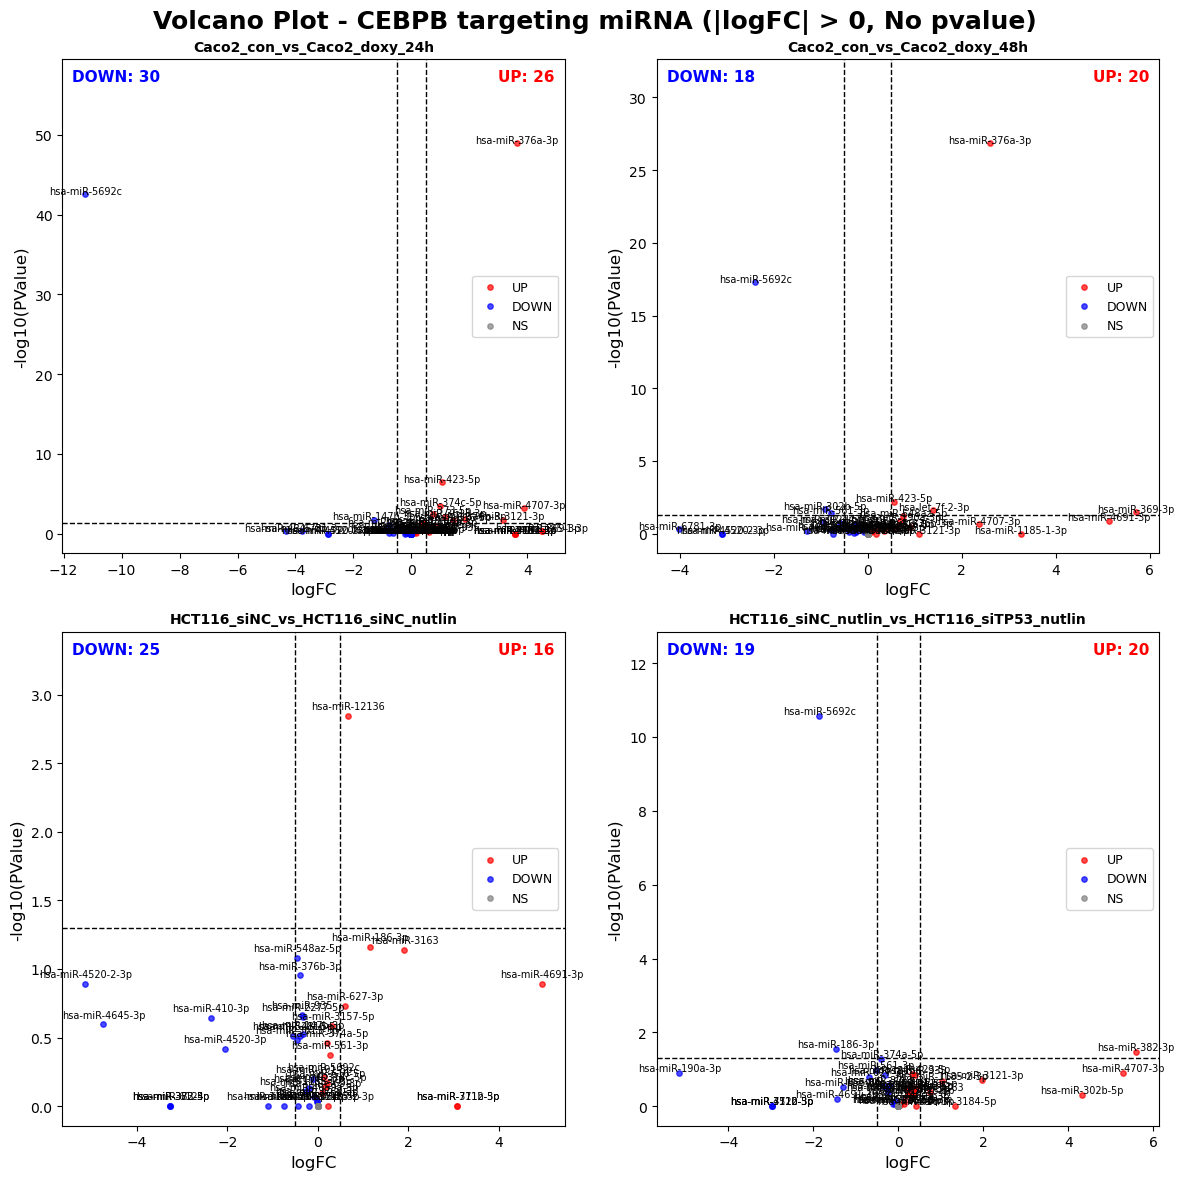

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

fig, axes = plt.subplots(2, 2, figsize=(12, 12))
plt.subplots_adjust(wspace=0.4, hspace=0.4)
axes = axes.flatten()

for ax, (name, fname) in zip(axes, files):
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df["-log10P"] = -np.log10(df["PValue"])

    def classify(row):
        if row["logFC"] > 0:
            return "UP"
        elif  row["logFC"] < -0:
            return "DOWN"
        else:
            return "NS"

    df["group"] = df.apply(classify, axis=1)

    colors = {"UP": "red", "DOWN": "blue", "NS": "gray"}
    for grp, color in colors.items():
        sub = df[df["group"] == grp]
        ax.scatter(sub["logFC"], sub["-log10P"], c=color, s=15, alpha=0.7, label=grp)

    ax.axhline(-np.log10(0.05), color="black", linestyle="--", linewidth=1)
    ax.axvline(0.5, color="black", linestyle="--", linewidth=1)
    ax.axvline(-0.5, color="black", linestyle="--", linewidth=1)

    up_n = (df["group"] == "UP").sum()
    down_n = (df["group"] == "DOWN").sum()

    ymin, ymax = ax.get_ylim()
    yrange = ymax - ymin
    ax.set_ylim(ymin, ymax + yrange * 0.15)

    ax.set_title(name, fontsize=10, fontweight="bold")
    ax.set_xlabel("logFC", fontsize=12)
    ax.set_ylabel("-log10(PValue)", fontsize=12)
    ax.legend(fontsize=9)

    ax.text(0.98, 0.98, f"UP: {up_n}", transform=ax.transAxes,
            ha="right", va="top", fontsize=11, color="red", fontweight="bold")
    ax.text(0.02, 0.98, f"DOWN: {down_n}", transform=ax.transAxes,
            ha="left", va="top", fontsize=11, color="blue", fontweight="bold")

    for mirna, row in df[df["group"] != "NS"].iterrows():
        ax.text(row["logFC"], row["-log10P"] + 0.05, mirna,
                fontsize=7, ha="center", color="black")

plt.suptitle("Volcano Plot - CEBPB targeting miRNA (|logFC| > 0, No pvalue)", fontsize=18, fontweight="bold")
plt.tight_layout()
plt.show()

# Scatter plot

In [80]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

data = {}
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    df = df[df["PValue"] < 0.05]
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.5]
    else:
        df = df[df["logFC"] > 0.5]
    data[name] = df

hct116_sinc   = set(data["HCT116_siNC_vs_HCT116_siNC_nutlin"].index)
caco2_24h     = set(data["Caco2_con_vs_Caco2_doxy_24h"].index)
hct116_sitp53 = set(data["HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin"].index)

inter1 = hct116_sinc & caco2_24h
inter2 = hct116_sinc & hct116_sitp53

pairs = []
titles = []

if inter1:
    pairs.append([
        ("HCT116_siNC_vs_siNC_nutlin\n(UP)", data["HCT116_siNC_vs_HCT116_siNC_nutlin"].loc[sorted(inter1)]),
        ("Caco2_con_vs_doxy_24h\n(UP)",      data["Caco2_con_vs_Caco2_doxy_24h"].loc[sorted(inter1)])
    ])
    titles.append("HCT116 siNC nutlin UP ∩ Caco2 24h UP")

if inter2:
    pairs.append([
        ("HCT116_siNC_vs_siNC_nutlin\n(UP)",            data["HCT116_siNC_vs_HCT116_siNC_nutlin"].loc[sorted(inter2)]),
        ("HCT116_siNC_nutlin_vs_siTP53_nutlin\n(DOWN)", data["HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin"].loc[sorted(inter2)])
    ])
    titles.append("HCT116 siNC nutlin UP ∩ HCT116 siTP53 DOWN")

if not pairs:
    print("교집합이 없습니다.")
else:
    n_cols = len(pairs) * 2
    max_rows = max(len(df) for pair in pairs for _, df in pair)

    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3, max_rows * 0.4 + 3))
    plt.subplots_adjust(wspace=2.0)

    if n_cols == 1:
        axes = [axes]

    col = 0
    for pair, title in zip(pairs, titles):
        max_r = max(len(df) for _, df in pair)
        for ax, (name, df) in zip([axes[col], axes[col+1]], pair):
            count = len(df)
            logfc = df[["logFC"]]
            pad_rows = max_r - count
            if pad_rows > 0:
                pad_df = pd.DataFrame([[None]] * pad_rows, columns=["logFC"], index=[""] * pad_rows)
                logfc_padded = pd.concat([logfc, pad_df])
            else:
                logfc_padded = logfc
            mask = logfc_padded.isnull()
            sns.heatmap(
                logfc_padded.astype(float),
                ax=ax, cmap="bwr", center=0, cbar=False,
                linewidths=0.5, linecolor="black", mask=mask
            )
            ax.set_aspect(0.8)
            ax.yaxis.tick_right()
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
            ax.text(-0.25, 0.5, name, rotation=90,
                    va="center", ha="center",
                    transform=ax.transAxes, fontsize=11)
            ax.text(0.5, 1.02, f"n = {count}",
                    transform=ax.transAxes,
                    ha="center", va="bottom",
                    fontsize=12, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("")

        axes[col].set_title(title, fontsize=11, fontweight="bold", pad=30)
        col += 2

    fig.suptitle("Intersecting miRNAs - Heatmap", fontsize=14, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()

교집합이 없습니다.


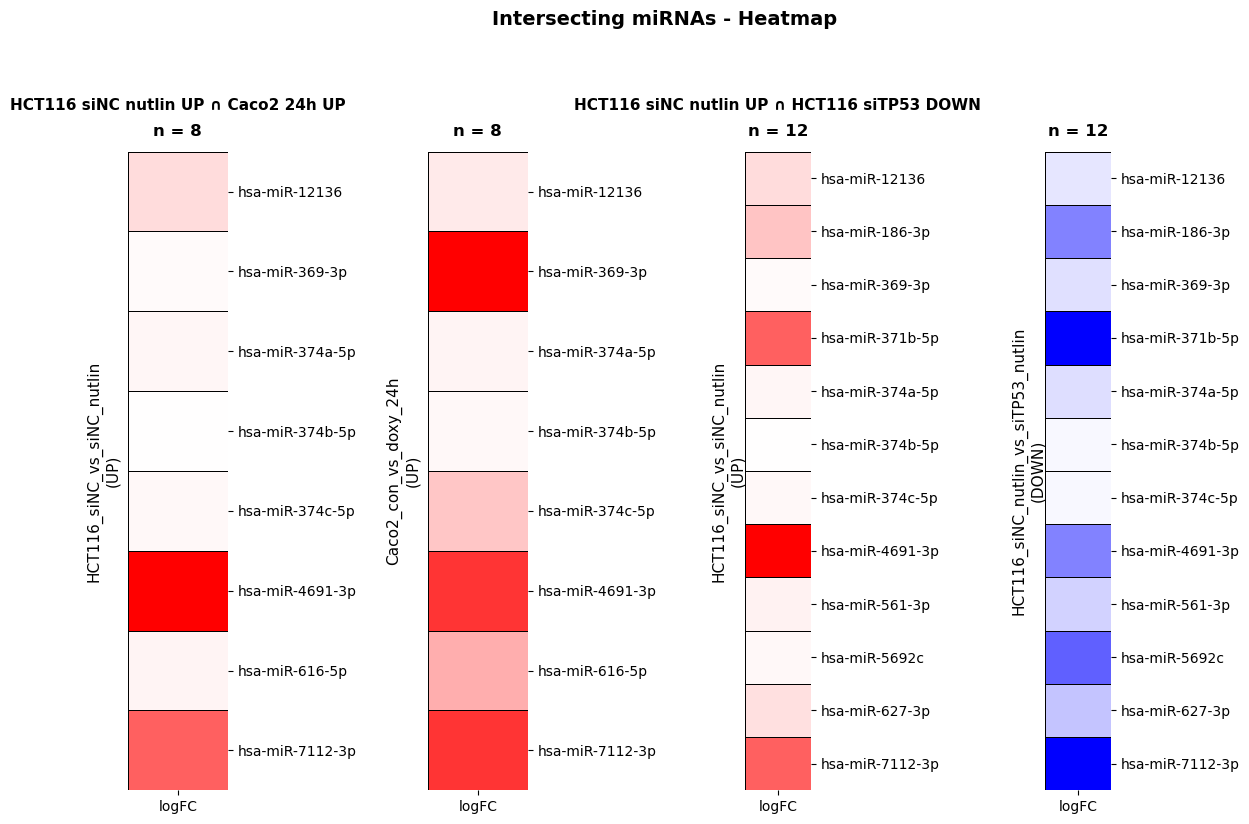

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

data = {}
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < -0.0]
    else:
        df = df[df["logFC"] > 0.0]
    data[name] = df

hct116_sinc   = set(data["HCT116_siNC_vs_HCT116_siNC_nutlin"].index)
caco2_24h     = set(data["Caco2_con_vs_Caco2_doxy_24h"].index)
hct116_sitp53 = set(data["HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin"].index)

inter1 = hct116_sinc & caco2_24h
inter2 = hct116_sinc & hct116_sitp53

pairs = []
titles = []

if inter1:
    pairs.append([
        ("HCT116_siNC_vs_siNC_nutlin\n(UP)", data["HCT116_siNC_vs_HCT116_siNC_nutlin"].loc[sorted(inter1)]),
        ("Caco2_con_vs_doxy_24h\n(UP)",      data["Caco2_con_vs_Caco2_doxy_24h"].loc[sorted(inter1)])
    ])
    titles.append("HCT116 siNC nutlin UP ∩ Caco2 24h UP")

if inter2:
    pairs.append([
        ("HCT116_siNC_vs_siNC_nutlin\n(UP)",            data["HCT116_siNC_vs_HCT116_siNC_nutlin"].loc[sorted(inter2)]),
        ("HCT116_siNC_nutlin_vs_siTP53_nutlin\n(DOWN)", data["HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin"].loc[sorted(inter2)])
    ])
    titles.append("HCT116 siNC nutlin UP ∩ HCT116 siTP53 DOWN")

if not pairs:
    print("교집합이 없습니다.")
else:
    n_cols = len(pairs) * 2
    max_rows = max(len(df) for pair in pairs for _, df in pair)

    fig, axes = plt.subplots(1, n_cols, figsize=(n_cols * 3, max_rows * 0.4 + 3))
    plt.subplots_adjust(wspace=2.0)

    if n_cols == 1:
        axes = [axes]

    col = 0
    for pair, title in zip(pairs, titles):
        max_r = max(len(df) for _, df in pair)
        for ax, (name, df) in zip([axes[col], axes[col+1]], pair):
            count = len(df)
            logfc = df[["logFC"]]
            pad_rows = max_r - count
            if pad_rows > 0:
                pad_df = pd.DataFrame([[None]] * pad_rows, columns=["logFC"], index=[""] * pad_rows)
                logfc_padded = pd.concat([logfc, pad_df])
            else:
                logfc_padded = logfc
            mask = logfc_padded.isnull()
            sns.heatmap(
                logfc_padded.astype(float),
                ax=ax, cmap="bwr", center=0, cbar=False,
                linewidths=0.5, linecolor="black", mask=mask
            )
            ax.set_aspect(0.8)
            ax.yaxis.tick_right()
            ax.set_yticklabels(ax.get_yticklabels(), fontsize=10, rotation=0)
            ax.text(-0.25, 0.5, name, rotation=90,
                    va="center", ha="center",
                    transform=ax.transAxes, fontsize=11)
            ax.text(0.5, 1.02, f"n = {count}",
                    transform=ax.transAxes,
                    ha="center", va="bottom",
                    fontsize=12, fontweight="bold")
            ax.set_xlabel("")
            ax.set_ylabel("")

        axes[col].set_title(title, fontsize=11, fontweight="bold", pad=30)
        col += 2

    fig.suptitle("Intersecting miRNAs - Heatmap", fontsize=14, fontweight="bold", y=1.05)
    plt.tight_layout()
    plt.show()

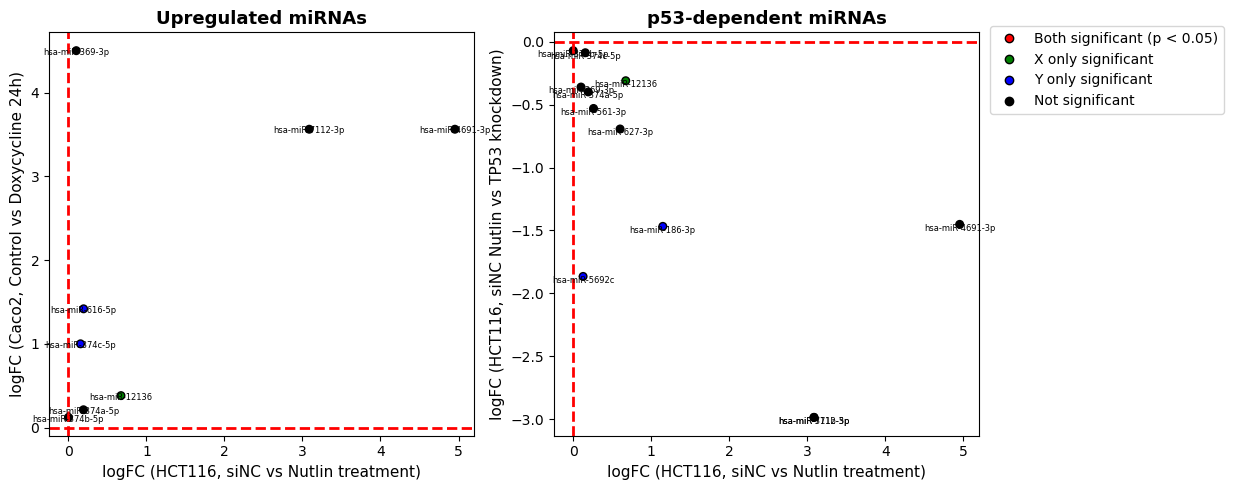

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

base = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/"
files = [
    ("Caco2_con_vs_Caco2_doxy_24h", "caco2_con_vs_caco2_doxy_24h.csv"),
    ("Caco2_con_vs_Caco2_doxy_48h", "caco2_con_vs_caco2_doxy_48h.csv"),
    ("HCT116_siNC_vs_HCT116_siNC_nutlin", "hct116_sinc_vs_hct116_sinc_nutlin.csv"),
    ("HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin", "hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv")
]

mirdb = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv")
mir_cebpb = mirdb[mirdb["GeneSymbol"] == "CEBPB"]["miRNA"].unique()

data = {}
for name, fname in files:
    df = pd.read_csv(base + fname, index_col=0)
    df = df[df.index.isin(mir_cebpb)]
    if name == "HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin":
        df = df[df["logFC"] < 0]
    else:
        df = df[df["logFC"] > 0]
    data[name] = df

hct116_sinc   = set(data["HCT116_siNC_vs_HCT116_siNC_nutlin"].index)
caco2_24h     = set(data["Caco2_con_vs_Caco2_doxy_24h"].index)
hct116_sitp53 = set(data["HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin"].index)

inter1 = sorted(hct116_sinc & caco2_24h)
inter2 = sorted(hct116_sinc & hct116_sitp53)


def plot_ax(ax, df1, df2, genes, title, xlabel, ylabel):

    df1 = df1.loc[genes]
    df2 = df2.loc[genes]

    x = df1["logFC"]
    y = df2["logFC"]

    p1 = df1["PValue"]
    p2 = df2["PValue"]

    colors = []
    for a, b in zip(p1, p2):
        if (a < 0.05) and (b < 0.05):
            colors.append("red")
        elif (a < 0.05):
            colors.append("green")
        elif (b < 0.05):
            colors.append("blue")
        else:
            colors.append("black")

    ax.scatter(x, y, c=colors, s=30, edgecolors='k')

    ax.axhline(0, linestyle='--', linewidth=2, color='red')
    ax.axvline(0, linestyle='--', linewidth=2, color='red')

    for gene, xi, yi in zip(genes, x, y):
        ax.text(xi, yi - 0.05, gene, fontsize=6, ha='center')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

if inter1:
    plot_ax(
        axes[0],
        data["HCT116_siNC_vs_HCT116_siNC_nutlin"],
        data["Caco2_con_vs_Caco2_doxy_24h"],
        inter1,
        "Upregulated miRNAs",
        "logFC (HCT116, siNC vs Nutlin treatment)",
        "logFC (Caco2, Control vs Doxycycline 24h)"
    )

if inter2:
    plot_ax(
        axes[1],
        data["HCT116_siNC_vs_HCT116_siNC_nutlin"],
        data["HCT116_siNC_nutlin_vs_HCT116_siTP53_nutlin"],
        inter2,
        "p53-dependent miRNAs",
        "logFC (HCT116, siNC vs Nutlin treatment)",
        "logFC (HCT116, siNC Nutlin vs TP53 knockdown)"
    )

legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Both significant (p < 0.05)',
           markerfacecolor='red', markersize=6, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='X only significant',
           markerfacecolor='green', markersize=6, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Y only significant',
           markerfacecolor='blue', markersize=6, markeredgecolor='k'),
    Line2D([0], [0], marker='o', color='w', label='Not significant',
           markerfacecolor='black', markersize=6, markeredgecolor='k')
]

fig.legend(
    handles=legend_elements,
    loc='center right',
    bbox_to_anchor=(1.03, 0.85),
    fontsize=10
)

plt.tight_layout()
plt.subplots_adjust(right=0.82)

plt.show()

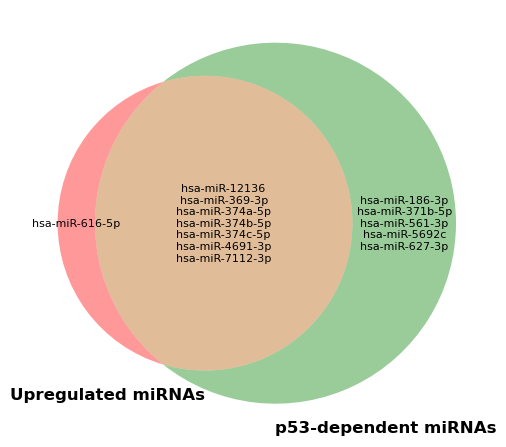

In [63]:
from matplotlib_venn import venn2
import matplotlib.pyplot as plt

set1 = set(inter1)
set2 = set(inter2)

plt.figure(figsize=(6,6))

v = venn2([set1, set2], set_labels=("Upregulated miRNAs", "p53-dependent miRNAs"))

for lbl in v.set_labels:
    if lbl:
        lbl.set_fontsize(12)
        lbl.set_fontweight('bold')

if v.get_label_by_id('10'):
    v.get_label_by_id('10').set_text('\n'.join(sorted(set1 - set2)))
    v.get_label_by_id('10').set_fontsize(8)

if v.get_label_by_id('01'):
    v.get_label_by_id('01').set_text('\n'.join(sorted(set2 - set1)))
    v.get_label_by_id('01').set_fontsize(8)

if v.get_label_by_id('11'):
    v.get_label_by_id('11').set_text('\n'.join(sorted(set1 & set2)))
    v.get_label_by_id('11').set_fontsize(8)

plt.show()

# mRNA

In [195]:
import pandas as pd

file_path = "/home/NAS/Coloncancer/rawData/miRNA_CRC/miRDB_v6.0_prediction_result.txt"

columns = ["miRNA", "Target_ID", "Score"]
df = pd.read_csv(file_path, sep="\t", names=columns)

df.head()

,miRNA,Target_ID,Score
0,cfa-miR-1185,XM_537211,59.343810
1,cfa-miR-1185,XM_536047,54.527000
2,cfa-miR-1185,XM_005617022,55.171633
3,cfa-miR-1185,XM_014117861,57.440906
4,cfa-miR-1185,XM_014107884,57.151900


In [196]:
df= df[df['miRNA'].str.contains("hsa")].sort_values(by='Score', ascending=False)

In [198]:
import mygene
mg = mygene.MyGeneInfo()

target_ids = df['Target_ID'].unique().tolist()
query_result = mg.querymany(target_ids, scopes='refseq', fields='symbol', species='human')

import pandas as pd
mapping_df = pd.DataFrame(query_result)
mapping_df = mapping_df[['query', 'symbol']].rename(columns={'query':'Target_ID', 'symbol':'GeneSymbol'})

df = df.merge(mapping_df, on='Target_ID', how='left')
df.head()

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed
86 input query terms found no hit:	['NM_001242791', 'NM_001242502', 'NM_001286549', 'NM_182832', 'NM_032374', 'NM_001014442', 'NM_00131


,miRNA,Target_ID,Score,GeneSymbol
0,hsa-miR-5011-5p,NM_001308248,100.0,EVI5
1,hsa-miR-5011-5p,NM_001025369,100.0,VEGFA
2,hsa-miR-5011-5p,NM_001171623,100.0,VEGFA
3,hsa-miR-190a-3p,NM_018836,100.0,AJAP1
4,hsa-miR-6867-5p,NM_015185,100.0,ARHGEF9


In [199]:
df.to_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv", index=False)

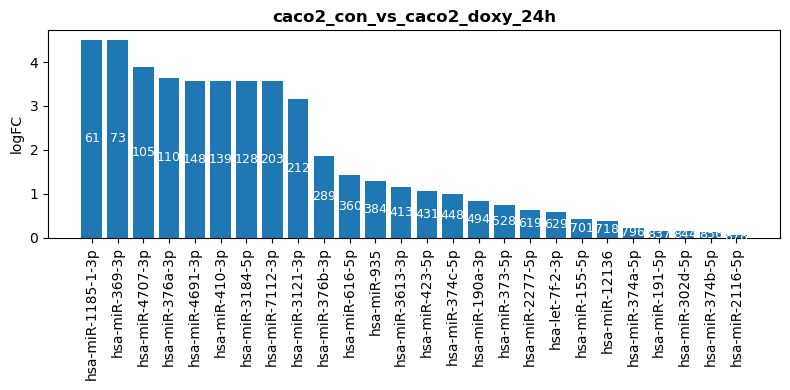

In [13]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/caco2_con_vs_caco2_doxy_24h.csv"
title = os.path.splitext(os.path.basename(csv_path))[0]

df = pd.read_csv(csv_path)

df["_ranking"] = df["logFC"].rank(method="first", ascending=False).astype(int)

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")

index = index[index["GeneSymbol"] == "CEBPB"]
index = index.drop_duplicates(subset=["miRNA"])

mapping = index.set_index("miRNA")["GeneSymbol"]

df["mRNA"] = df["Unnamed: 0"].map(mapping)
df = df.dropna(subset=["mRNA"])

df["Ranking"] = df["_ranking"]
df = df.drop(columns=["_ranking"])

df_pos = df[df["logFC"] > 0].sort_values("logFC", ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(df_pos["Unnamed: 0"], df_pos["logFC"])
plt.xticks(rotation=90)

for bar, rank in zip(bars, df_pos["Ranking"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        str(rank),
        ha="center",
        va="center",
        color="white",
        fontsize=9
    )

plt.ylabel("logFC")
plt.title(title, fontweight="bold")
plt.tight_layout()
plt.show()

In [18]:
df_pos.to_csv("/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/caco2_con_vs_caco2_doxy_24h.csv", index=False)

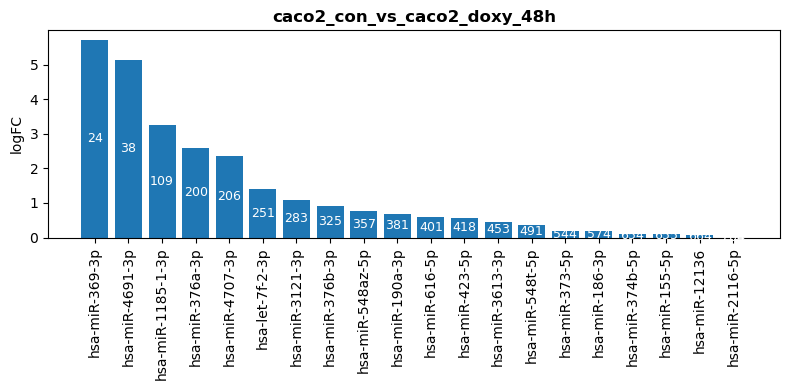

In [19]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/caco2_con_vs_caco2_doxy_48h.csv"
title = os.path.splitext(os.path.basename(csv_path))[0]

df = pd.read_csv(csv_path)

df["_ranking"] = df["logFC"].rank(method="first", ascending=False).astype(int)

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")

index = index[index["GeneSymbol"] == "CEBPB"]
index = index.drop_duplicates(subset=["miRNA"])

mapping = index.set_index("miRNA")["GeneSymbol"]

df["mRNA"] = df["Unnamed: 0"].map(mapping)
df = df.dropna(subset=["mRNA"])

df["Ranking"] = df["_ranking"]
df = df.drop(columns=["_ranking"])

df_pos = df[df["logFC"] > 0].sort_values("logFC", ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(df_pos["Unnamed: 0"], df_pos["logFC"])
plt.xticks(rotation=90)

for bar, rank in zip(bars, df_pos["Ranking"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        str(rank),
        ha="center",
        va="center",
        color="white",
        fontsize=9
    )

plt.ylabel("logFC")
plt.title(title, fontweight="bold")
plt.tight_layout()
plt.show()

In [20]:
df_pos.to_csv("/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/caco2_con_vs_caco2_doxy_48h.csv", index=False)

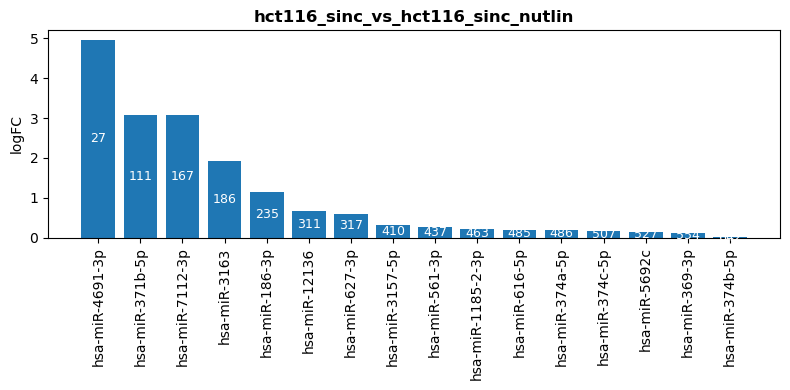

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/hct116_sinc_vs_hct116_sinc_nutlin.csv"
title = os.path.splitext(os.path.basename(csv_path))[0]

df = pd.read_csv(csv_path)

df["_ranking"] = df["logFC"].rank(method="first", ascending=False).astype(int)

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")

index = index[index["GeneSymbol"] == "CEBPB"]
index = index.drop_duplicates(subset=["miRNA"])

mapping = index.set_index("miRNA")["GeneSymbol"]

df["mRNA"] = df["Unnamed: 0"].map(mapping)
df = df.dropna(subset=["mRNA"])

df["Ranking"] = df["_ranking"]
df = df.drop(columns=["_ranking"])

df_pos = df[df["logFC"] > 0].sort_values("logFC", ascending=False)

plt.figure(figsize=(8, 4))
bars = plt.bar(df_pos["Unnamed: 0"], df_pos["logFC"])
plt.xticks(rotation=90)

for bar, rank in zip(bars, df_pos["Ranking"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        str(rank),
        ha="center",
        va="center",
        color="white",
        fontsize=9
    )

plt.ylabel("logFC")
plt.title(title, fontweight="bold")
plt.tight_layout()
plt.show()

In [23]:
df_pos.to_csv("/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/hct116_sinc_vs_hct116_sinc_nutlin.csv", index=False)

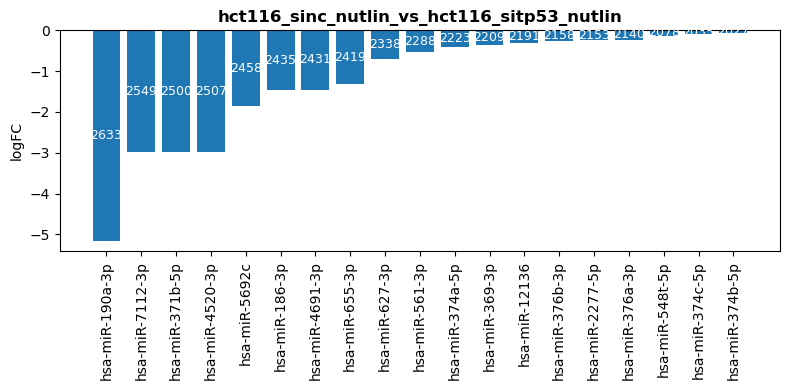

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt

csv_path = "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv"
title = os.path.splitext(os.path.basename(csv_path))[0]

df = pd.read_csv(csv_path)

df["_ranking"] = df["logFC"].rank(method="first", ascending=False).astype(int)

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")

index = index[index["GeneSymbol"] == "CEBPB"]
index = index.drop_duplicates(subset=["miRNA"])

mapping = index.set_index("miRNA")["GeneSymbol"]

df["mRNA"] = df["Unnamed: 0"].map(mapping)
df = df.dropna(subset=["mRNA"])

df["Ranking"] = df["_ranking"]
df = df.drop(columns=["_ranking"])

df_pos = df[df["logFC"] < 0].sort_values("logFC", ascending=True)

plt.figure(figsize=(8, 4))
bars = plt.bar(df_pos["Unnamed: 0"], df_pos["logFC"])
plt.xticks(rotation=90)

for bar, rank in zip(bars, df_pos["Ranking"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() / 2,
        str(rank),
        ha="center",
        va="center",
        color="white",
        fontsize=9
    )

plt.ylabel("logFC")
plt.title(title, fontweight="bold")
plt.tight_layout()
plt.show()

In [25]:
df_pos.to_csv("/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/List_sorting/hct116_sinc_nutlin_vs_hct116_sitp53_nutlin.csv", index=False)

In [241]:
########## timeline ########

In [26]:
import os
import pandas as pd
import matplotlib.pyplot as plt

df24 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_(timeline)/Caco2_doxy_24h_decrease_top20.csv"
)

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")

index = index[index["GeneSymbol"] == "CEBPB"]
index = index.drop_duplicates(subset=["miRNA"])

mapping = index.set_index("miRNA")["GeneSymbol"]

df24["mRNA"] = df24["Unnamed: 0"].map(mapping)
df24 = df24.dropna(subset=["mRNA"])

In [27]:
import os
import pandas as pd
import matplotlib.pyplot as plt

df48 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_(timeline)/Caco2_doxy_48h_increase_top20.csv")

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")

index = index[index["GeneSymbol"] == "CEBPB"]
index = index.drop_duplicates(subset=["miRNA"])

mapping = index.set_index("miRNA")["GeneSymbol"]

df48["mRNA"] = df48["Unnamed: 0"].map(mapping)
df48 = df48.dropna(subset=["mRNA"])

In [28]:
import os
import pandas as pd
import matplotlib.pyplot as plt

df0 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_(timeline)/Caco2_within_sd.csv")

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")

index = index[index["GeneSymbol"] == "CEBPB"]
index = index.drop_duplicates(subset=["miRNA"])

mapping = index.set_index("miRNA")["GeneSymbol"]

df0["mRNA"] = df0["Unnamed: 0"].map(mapping)
df0 = df0.dropna(subset=["mRNA"])

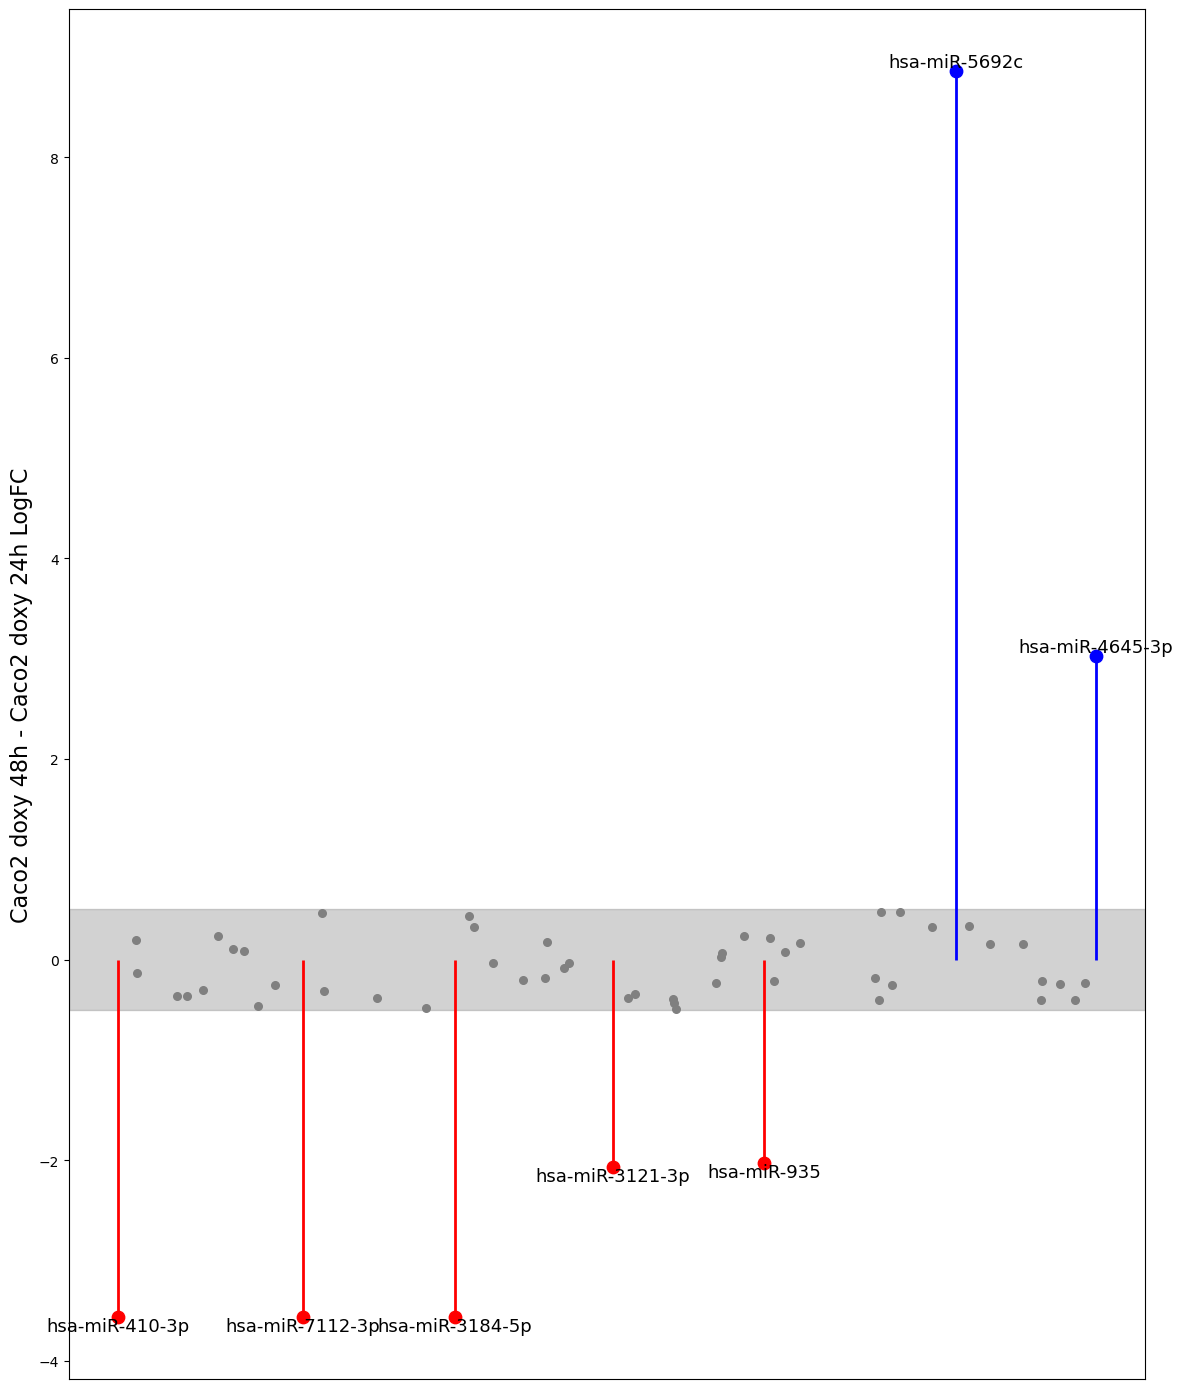

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df24_p = df24[["Unnamed: 0", "residual_48h_minus_24h"]].copy()
df48_p = df48[["Unnamed: 0", "residual_48h_minus_24h"]].copy()
df_plot = pd.concat([df24_p, df48_p], axis=0).reset_index(drop=True)

y = df_plot["residual_48h_minus_24h"].values
labels = df_plot["Unnamed: 0"].astype(str).values

np.random.seed(0)

n = len(y)
x_base = np.linspace(-10, 10, n)
x_jitter = np.random.uniform(-1.2, 1.2, size=n)
x = x_base + x_jitter

plt.figure(figsize=(12, 14))

grey_half_width = 0.5
plt.axhspan(-grey_half_width, grey_half_width, color="gray", alpha=0.35)

mask_pos = y > grey_half_width
mask_neg = y < -grey_half_width

plt.vlines(
    x[mask_pos], 0, y[mask_pos],
    color="blue", linewidth=2
)
plt.scatter(
    x[mask_pos], y[mask_pos],
    color="blue", s=80
)

plt.vlines(
    x[mask_neg], 0, y[mask_neg],
    color="red", linewidth=2
)
plt.scatter(
    x[mask_neg], y[mask_neg],
    color="red", s=80
)

for xi, yi, lab in zip(x[mask_pos], y[mask_pos], labels[mask_pos]):
    plt.text(xi, yi, lab, ha="center", va="bottom", fontsize=13)

for xi, yi, lab in zip(x[mask_neg], y[mask_neg], labels[mask_neg]):
    plt.text(xi, yi, lab, ha="center", va="top", fontsize=13)

n0 = len(df0)
x0 = np.random.uniform(x.min(), x.max(), size=n0)
y0 = np.random.uniform(-grey_half_width, grey_half_width, size=n0)
plt.scatter(x0, y0, s=30, alpha=1, color="gray")

plt.xticks([])
plt.ylabel("Caco2 doxy 48h - Caco2 doxy 24h LogFC", fontsize=16)
plt.tight_layout()
plt.show()

In [31]:
df_plot

,Unnamed: 0,residual_48h_minus_24h
0,hsa-miR-410-3p,-3.561869
1,hsa-miR-7112-3p,-3.561869
2,hsa-miR-3184-5p,-3.561869
3,hsa-miR-3121-3p,-2.073747
4,hsa-miR-935,-2.032264
5,hsa-miR-5692c,8.857642
6,hsa-miR-4645-3p,3.025530


In [6]:
genes_upper = labels[y > grey_half_width]
genes_lower = labels[y < -grey_half_width]
genes_middle = labels[(y >= -grey_half_width) & (y <= grey_half_width)]

genes_df0 = df0["Unnamed: 0"].astype(str).values

print("=== Upper (above gray zone) ===")
print("\n".join(genes_upper))

print("\n=== Middle (gray zone, df_plot) ===")
print("\n".join(genes_middle))

print("\n=== Middle (gray zone, df0) ===")
print("\n".join(genes_df0))

print("\n=== Lower (below gray zone) ===")
print("\n".join(genes_lower))

=== Upper (above gray zone) ===
hsa-miR-5692c
hsa-miR-4645-3p

=== Middle (gray zone, df_plot) ===


=== Middle (gray zone, df0) ===
hsa-miR-376a-3p
hsa-miR-4707-3p
hsa-miR-376b-3p
hsa-miR-616-5p
hsa-miR-147b-3p
hsa-miR-3613-3p
hsa-miR-423-5p
hsa-miR-374c-5p
hsa-miR-190a-3p
hsa-miR-1185-1-3p
hsa-miR-369-3p
hsa-miR-6781-3p
hsa-miR-373-5p
hsa-miR-302b-5p
hsa-miR-2277-5p
hsa-miR-155-5p
hsa-miR-12136
hsa-let-7f-2-3p
hsa-miR-627-3p
hsa-miR-548t-5p
hsa-miR-3157-5p
hsa-miR-374a-5p
hsa-miR-191-5p
hsa-miR-374b-5p
hsa-miR-548az-5p
hsa-miR-302d-5p
hsa-miR-561-3p
hsa-miR-2116-5p
hsa-miR-4691-3p
hsa-miR-4520-2-3p
hsa-miR-4520-3p
hsa-miR-3163
hsa-miR-4659a-3p
hsa-miR-186-3p
hsa-miR-1185-2-3p
hsa-miR-2682-3p
hsa-miR-3178
hsa-miR-371b-5p
hsa-miR-382-3p
hsa-miR-4255
hsa-miR-4313
hsa-miR-4659b-3p
hsa-miR-4711-5p
hsa-miR-4716-5p
hsa-miR-5011-5p
hsa-miR-5680
hsa-miR-5692b
hsa-miR-6124
hsa-miR-655-3p

=== Lower (below gray zone) ===
hsa-miR-410-3p
hsa-miR-7112-3p
hsa-miR-3184-5p
hsa-miR-3121-3p
hsa-miR-935

In [297]:
########## Scatter plot #############

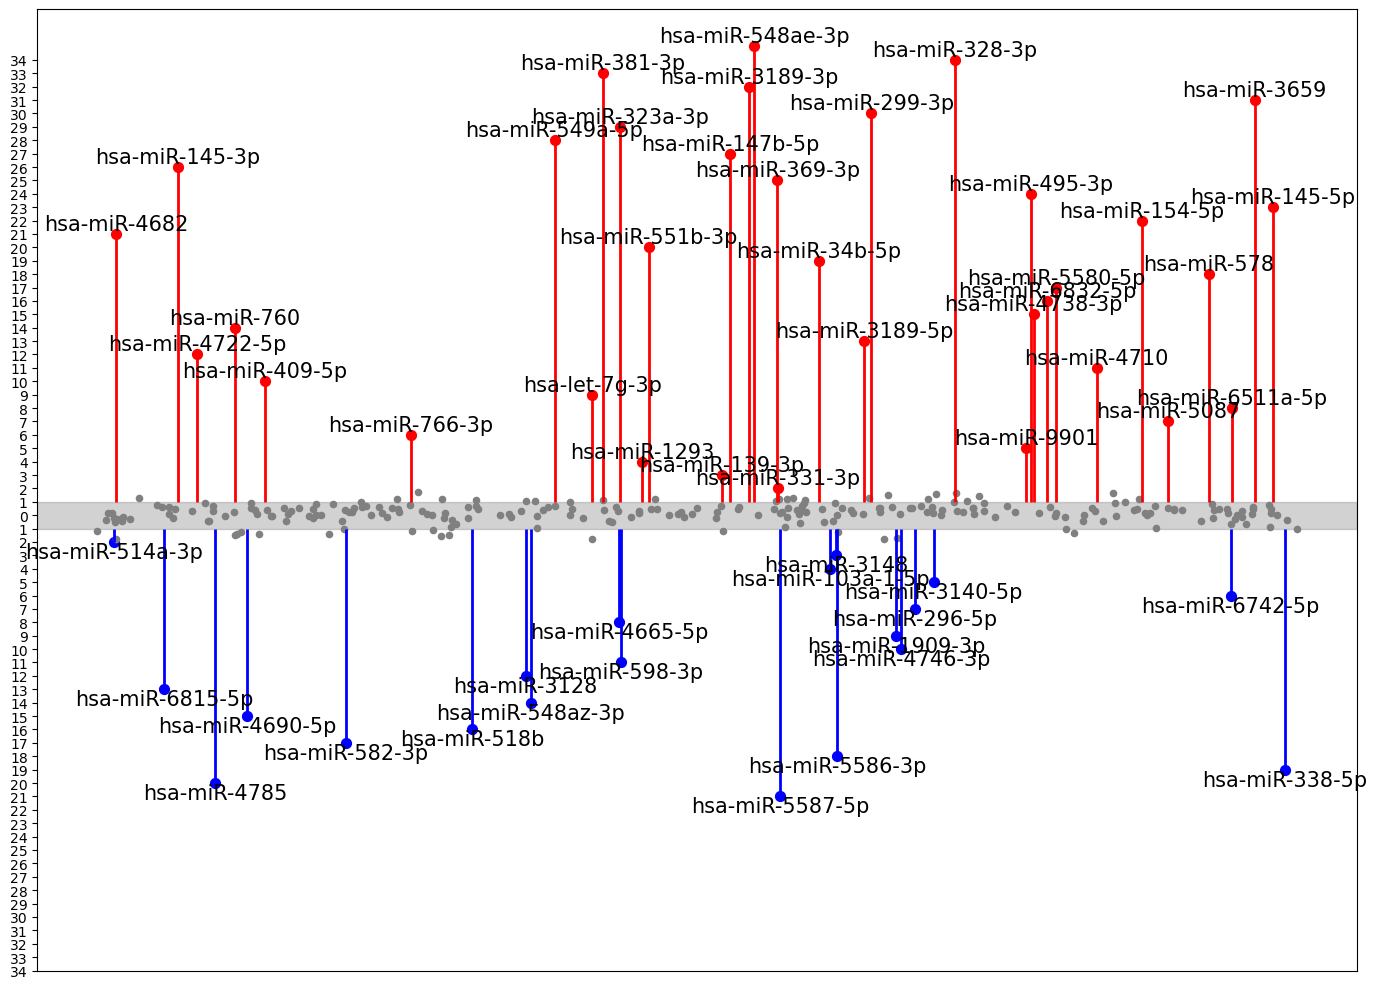

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_red = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_caco24_vs_HCT116_nutlin/df_caco2_higher.csv"
)
df_blue = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_caco24_vs_HCT116_nutlin/df_hct116_higher.csv"
)
df0 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_caco24_vs_HCT116_nutlin/df_within_sd.csv"
)

y_red = df_red["Residual"].values
lab_red = df_red["miRNA"].astype(str).values

y_blue = df_blue["Residual"].values
lab_blue = df_blue["miRNA"].astype(str).values

np.random.seed(0)
x_red = np.random.uniform(-8, 8, size=len(y_red))
x_blue = np.random.uniform(-8, 8, size=len(y_blue))
x0 = np.random.uniform(-8, 8, size=len(df0))
y0 = df0["Residual"].values

grey_half = 1.0

rank_red = np.argsort(np.argsort(y_red)) + 1 if len(y_red) > 0 else np.array([])
rank_blue = np.argsort(np.argsort(y_blue)) + 1 if len(y_blue) > 0 else np.array([])

y_red_plot = grey_half + rank_red
y_blue_plot = -(grey_half + rank_blue)

plt.figure(figsize=(14, 10))
plt.axhspan(-grey_half, grey_half, color="gray", alpha=0.35)

if len(rank_red) > 0:
    plt.vlines(x_red, grey_half, y_red_plot, color="red", linewidth=2)
    plt.scatter(x_red, y_red_plot, color="red", s=50)
    for xi, yi, lab in zip(x_red, y_red_plot, lab_red):
        plt.text(xi, yi, lab, ha="center", va="bottom", fontsize=15)

if len(rank_blue) > 0:
    plt.vlines(x_blue, -grey_half, y_blue_plot, color="blue", linewidth=2)
    plt.scatter(x_blue, y_blue_plot, color="blue", s=50)
    for xi, yi, lab in zip(x_blue, y_blue_plot, lab_blue):
        plt.text(xi, yi, lab, ha="center", va="top", fontsize=15)

plt.scatter(x0, y0, s=20, alpha=1, color="gray")

plt.xticks([])

max_red = rank_red.max() if len(rank_red) > 0 else 0
max_blue = rank_blue.max() if len(rank_blue) > 0 else 0
ymax = max(max_red, max_blue)

if ymax > 0:
    yticks_pos = np.arange(1, ymax + 1, 1)
    yticks_neg = -np.arange(1, ymax + 1, 1)
    yticks = np.concatenate([yticks_neg, [0], yticks_pos])
    ytick_labels = [str(abs(int(v))) for v in yticks]
    plt.yticks(yticks, ytick_labels)


plt.tight_layout()
plt.show()

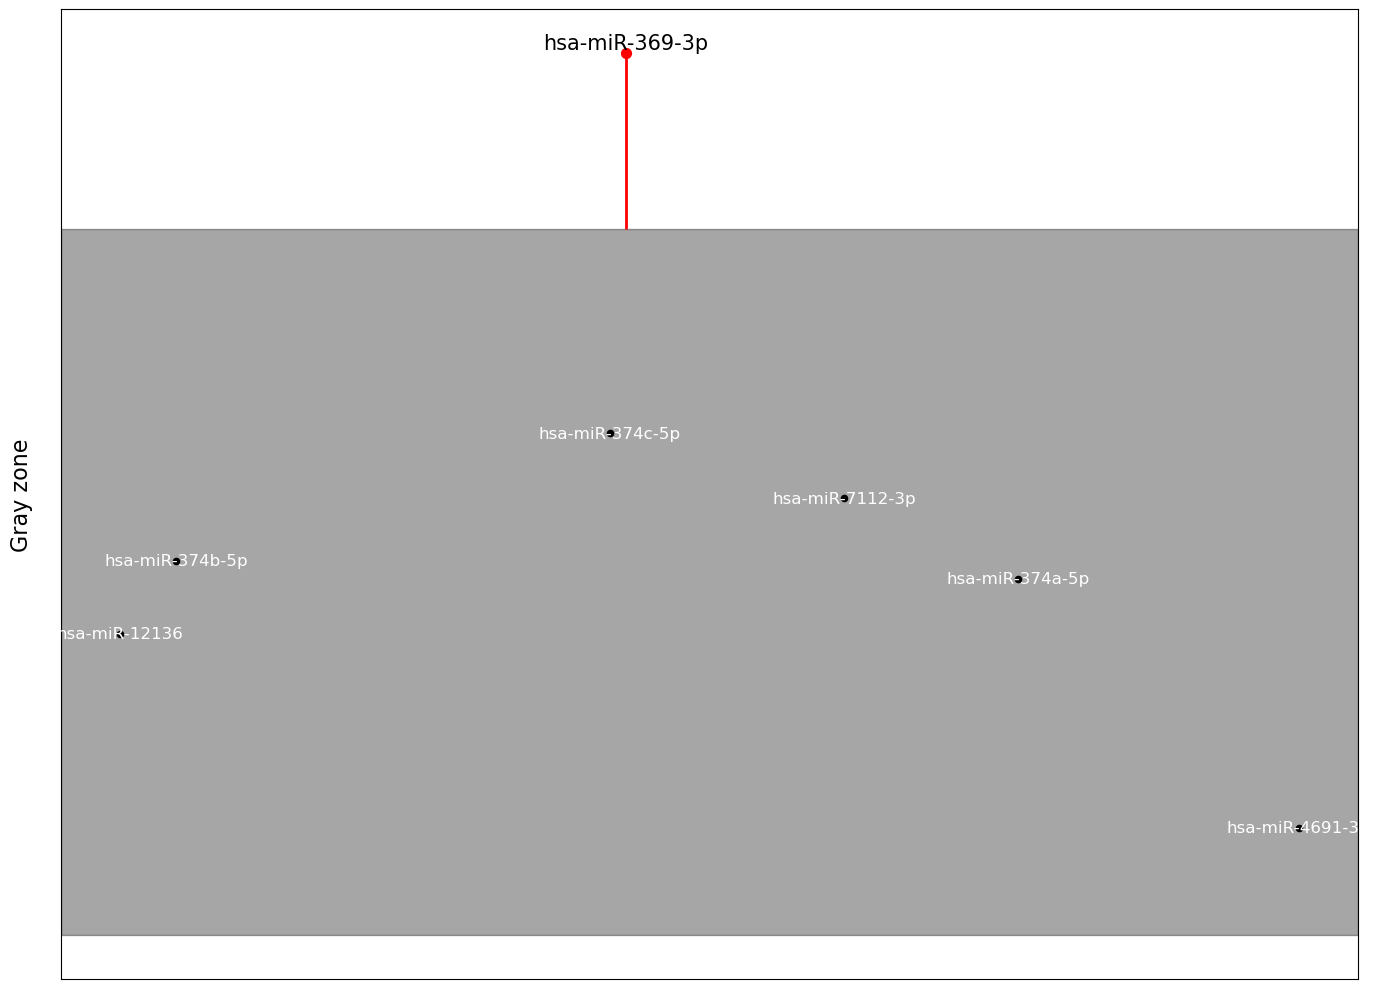

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")
index = index[index["GeneSymbol"] == "CEBPB"].drop_duplicates(subset=["miRNA"])
cebpb_mirna = set(index["miRNA"])

df_red = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_caco24_vs_HCT116_nutlin/df_caco2_higher.csv"
)
df_blue = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_caco24_vs_HCT116_nutlin/df_hct116_higher.csv"
)
df0 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_caco24_vs_HCT116_nutlin/df_within_sd.csv"
)

df_red = df_red[df_red["miRNA"].isin(cebpb_mirna)]
df_blue = df_blue[df_blue["miRNA"].isin(cebpb_mirna)]
df0 = df0[df0["miRNA"].isin(cebpb_mirna)]

y_red = df_red["Residual"].values
lab_red = df_red["miRNA"].astype(str).values

y_blue = df_blue["Residual"].values
lab_blue = df_blue["miRNA"].astype(str).values

y0 = df0["Residual"].values
lab0 = df0["miRNA"].astype(str).values

np.random.seed(0)
x_red = np.random.uniform(-8, 8, size=len(y_red))
x_blue = np.random.uniform(-8, 8, size=len(y_blue))
x0 = np.random.uniform(-8, 8, size=len(y0))

grey_half = 2.0

rank_red = np.argsort(np.argsort(y_red)) + 1 if len(y_red) > 0 else np.array([])
rank_blue = np.argsort(np.argsort(y_blue)) + 1 if len(y_blue) > 0 else np.array([])

y_red_plot = grey_half + rank_red
y_blue_plot = -(grey_half + rank_blue)

plt.figure(figsize=(14, 10))
plt.axhspan(-grey_half, grey_half, color="black", alpha=0.35)

if len(rank_red) > 0:
    plt.vlines(x_red, grey_half, y_red_plot, color="red", linewidth=2)
    plt.scatter(x_red, y_red_plot, color="red", s=50)
    for xi, yi, lab in zip(x_red, y_red_plot, lab_red):
        plt.text(xi, yi, lab, ha="center", va="bottom", fontsize=15)

if len(rank_blue) > 0:
    plt.vlines(x_blue, -grey_half, y_blue_plot, color="blue", linewidth=2)
    plt.scatter(x_blue, y_blue_plot, color="blue", s=50)
    for xi, yi, lab in zip(x_blue, y_blue_plot, lab_blue):
        plt.text(xi, yi, lab, ha="center", va="top", fontsize=12)

plt.scatter(x0, y0, s=20, alpha=1, color="black")
for xi, yi, lab in zip(x0, y0, lab0):
    plt.text(xi, yi, lab, ha="center", va="center", fontsize=12, color="white")

plt.xticks([])
plt.yticks([])
plt.ylabel("Gray zone", fontsize=16, labelpad=20)

plt.tight_layout()
plt.show()

In [36]:
import pandas as pd

df_plot_residual = pd.DataFrame({
    "miRNA": list(lab_red) + list(lab_blue) + list(lab0),
    "Residual": list(y_red) + list(y_blue) + list(y0),
    "Group": ["Red"]*len(y_red) + ["Blue"]*len(y_blue) + ["Gray"]*len(y0)
})

df_plot_residual

,miRNA,Residual,Group
0,hsa-miR-369-3p,4.398089,Red
1,hsa-miR-4691-3p,-1.391754,Gray
2,hsa-miR-7112-3p,0.474929,Gray
3,hsa-miR-374c-5p,0.844897,Gray
4,hsa-miR-12136,-0.291911,Gray
5,hsa-miR-374a-5p,0.019778,Gray
6,hsa-miR-374b-5p,0.121140,Gray


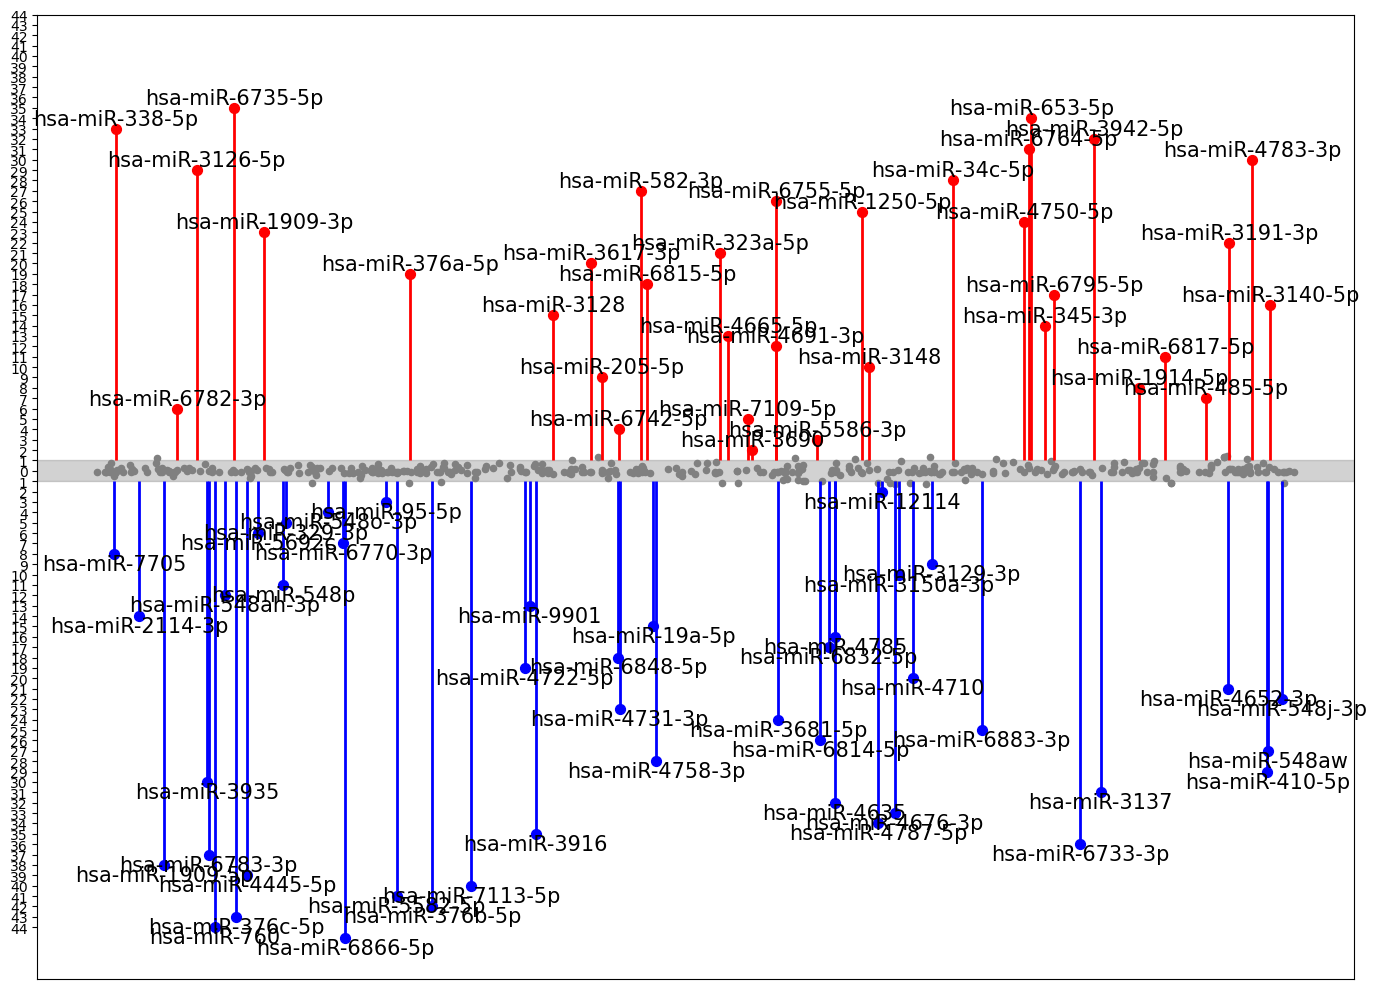

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df_red = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_HCT116_vs_HCT116_nutlin/df_hct116_higher.csv"
)
df_blue = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_HCT116_vs_HCT116_nutlin/df_tp53_higher.csv"
)
df0 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_HCT116_vs_HCT116_nutlin/df_within_sd.csv"
)

y_red = df_red["Residual"].values
lab_red = df_red["miRNA"].astype(str).values

y_blue = df_blue["Residual"].values
lab_blue = df_blue["miRNA"].astype(str).values

np.random.seed(0)
x_red = np.random.uniform(-8, 8, size=len(y_red))
x_blue = np.random.uniform(-8, 8, size=len(y_blue))
x0 = np.random.uniform(-8, 8, size=len(df0))
y0 = df0["Residual"].values

grey_half = 1.0

rank_red = np.argsort(np.argsort(y_red)) + 1 if len(y_red) > 0 else np.array([])
rank_blue = np.argsort(np.argsort(y_blue)) + 1 if len(y_blue) > 0 else np.array([])

y_red_plot = grey_half + rank_red
y_blue_plot = -(grey_half + rank_blue)

plt.figure(figsize=(14, 10))
plt.axhspan(-grey_half, grey_half, color="gray", alpha=0.35)

if len(rank_red) > 0:
    plt.vlines(x_red, grey_half, y_red_plot, color="red", linewidth=2)
    plt.scatter(x_red, y_red_plot, color="red", s=50)
    for xi, yi, lab in zip(x_red, y_red_plot, lab_red):
        plt.text(xi, yi, lab, ha="center", va="bottom", fontsize=15)

if len(rank_blue) > 0:
    plt.vlines(x_blue, -grey_half, y_blue_plot, color="blue", linewidth=2)
    plt.scatter(x_blue, y_blue_plot, color="blue", s=50)
    for xi, yi, lab in zip(x_blue, y_blue_plot, lab_blue):
        plt.text(xi, yi, lab, ha="center", va="top", fontsize=15)

plt.scatter(x0, y0, s=20, alpha=1, color="gray")

plt.xticks([])

max_red = rank_red.max() if len(rank_red) > 0 else 0
max_blue = rank_blue.max() if len(rank_blue) > 0 else 0
ymax = max(max_red, max_blue)

if ymax > 0:
    yticks_pos = np.arange(1, ymax + 1, 1)
    yticks_neg = -np.arange(1, ymax + 1, 1)
    yticks = np.concatenate([yticks_neg, [0], yticks_pos])
    ytick_labels = [str(abs(int(v))) for v in yticks]
    plt.yticks(yticks, ytick_labels)


plt.tight_layout()
plt.show()

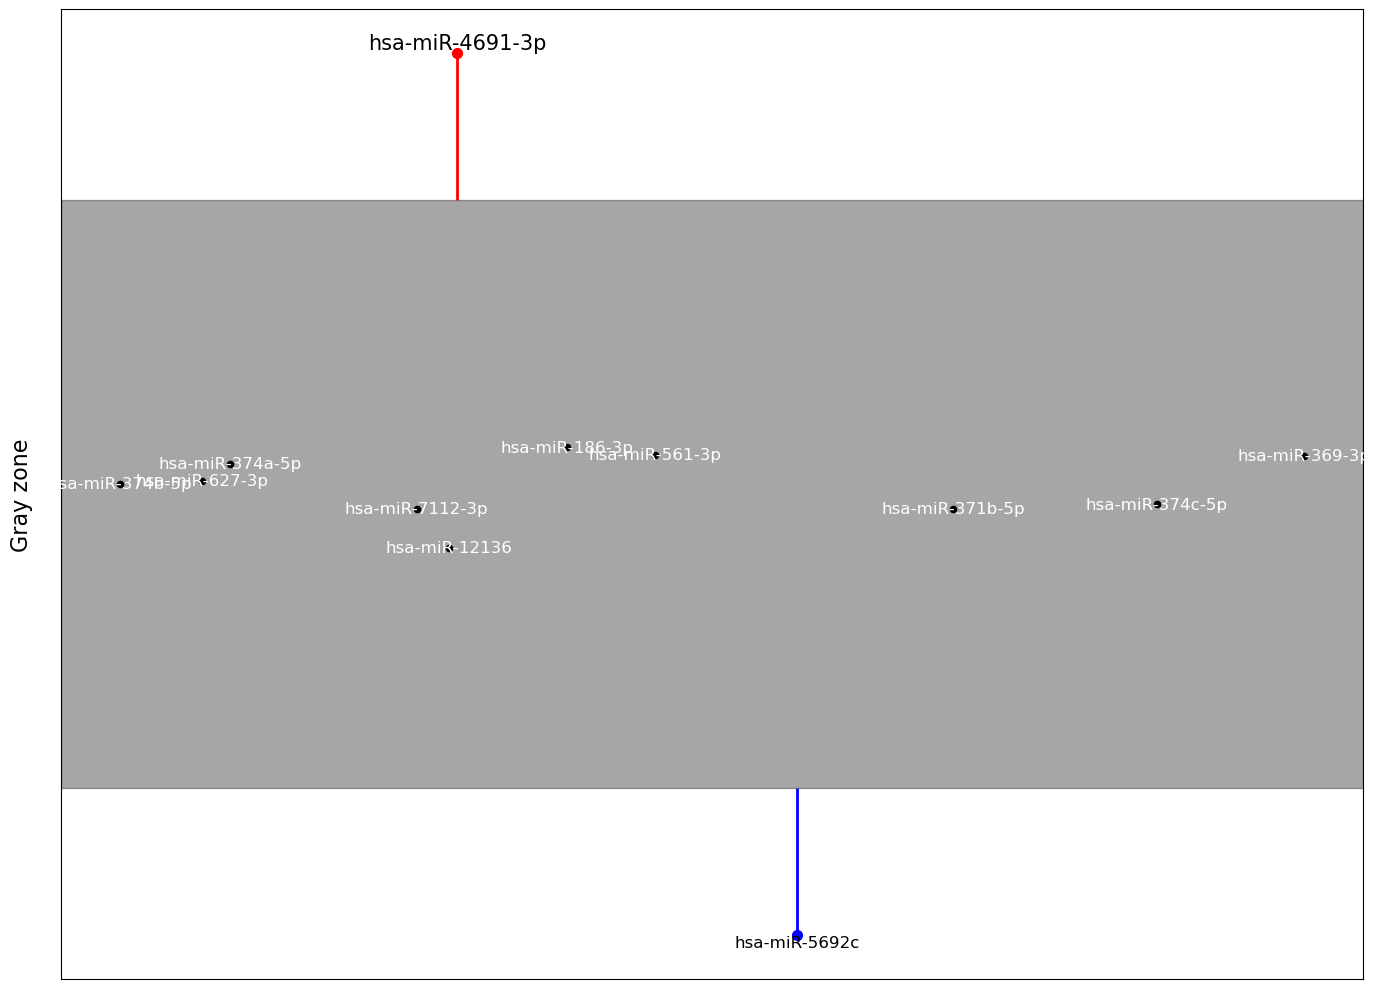

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

index = pd.read_csv("/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv")
index = index[index["GeneSymbol"] == "CEBPB"].drop_duplicates(subset=["miRNA"])
cebpb_mirna = set(index["miRNA"])

df_red = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_HCT116_vs_HCT116_nutlin/df_hct116_higher.csv"
)
df_blue = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_HCT116_vs_HCT116_nutlin/df_tp53_higher.csv"
)
df0 = pd.read_csv(
    "/home/Data_Drive_8TB/kykim/5. CRC (Myeloid)/Capture/miRNA/Gene_sorting_HCT116_vs_HCT116_nutlin/df_within_sd.csv"
)

df_red = df_red[df_red["miRNA"].isin(cebpb_mirna)]
df_blue = df_blue[df_blue["miRNA"].isin(cebpb_mirna)]
df0 = df0[df0["miRNA"].isin(cebpb_mirna)]

y_red = df_red["Residual"].values
lab_red = df_red["miRNA"].astype(str).values

y_blue = df_blue["Residual"].values
lab_blue = df_blue["miRNA"].astype(str).values

y0 = df0["Residual"].values
lab0 = df0["miRNA"].astype(str).values

np.random.seed(0)
x_red = np.random.uniform(-8, 8, size=len(y_red))
x_blue = np.random.uniform(-8, 8, size=len(y_blue))
x0 = np.random.uniform(-8, 8, size=len(y0))

grey_half = 2.0

rank_red = np.argsort(np.argsort(y_red)) + 1 if len(y_red) > 0 else np.array([])
rank_blue = np.argsort(np.argsort(y_blue)) + 1 if len(y_blue) > 0 else np.array([])

y_red_plot = grey_half + rank_red
y_blue_plot = -(grey_half + rank_blue)

plt.figure(figsize=(14, 10))
plt.axhspan(-grey_half, grey_half, color="black", alpha=0.35)

if len(rank_red) > 0:
    plt.vlines(x_red, grey_half, y_red_plot, color="red", linewidth=2)
    plt.scatter(x_red, y_red_plot, color="red", s=50)
    for xi, yi, lab in zip(x_red, y_red_plot, lab_red):
        plt.text(xi, yi, lab, ha="center", va="bottom", fontsize=15)

if len(rank_blue) > 0:
    plt.vlines(x_blue, -grey_half, y_blue_plot, color="blue", linewidth=2)
    plt.scatter(x_blue, y_blue_plot, color="blue", s=50)
    for xi, yi, lab in zip(x_blue, y_blue_plot, lab_blue):
        plt.text(xi, yi, lab, ha="center", va="top", fontsize=12)

plt.scatter(x0, y0, s=20, alpha=1, color="black")
for xi, yi, lab in zip(x0, y0, lab0):
    plt.text(xi, yi, lab, ha="center", va="center", fontsize=12, color="white")

plt.xticks([])
plt.yticks([])
plt.ylabel("Gray zone", fontsize=16, labelpad=20)

plt.tight_layout()
plt.show()

In [39]:
import pandas as pd

df_plot_residual = pd.DataFrame({
    "miRNA": list(lab_red) + list(lab_blue) + list(lab0),
    "Residual": list(y_red) + list(y_blue) + list(y0),
    "Group": ["Red"]*len(y_red) + ["Blue"]*len(y_blue) + ["Gray"]*len(y0)
})

df_plot_residual

,miRNA,Residual,Group
0,hsa-miR-4691-3p,-3.502347,Red
1,hsa-miR-5692c,1.736920,Blue
2,hsa-miR-186-3p,0.317688,Gray
3,hsa-miR-12136,-0.364517,Gray
4,hsa-miR-627-3p,0.091497,Gray
5,hsa-miR-561-3p,0.268594,Gray
6,hsa-miR-374a-5p,0.204743,Gray
7,hsa-miR-374c-5p,-0.068592,Gray
8,hsa-miR-369-3p,0.258862,Gray
9,hsa-miR-374b-5p,0.069343,Gray


In [40]:
import pandas as pd

input_path = "/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB.csv"
output_path = "/home/NAS/Coloncancer/rawData/miRNA_CRC/hsa_mirDB_CEBPB.csv"

df = pd.read_csv(input_path)
df_cebp = df[df["GeneSymbol"] == "CEBPB"].drop_duplicates(subset=["miRNA"])
df_cebp.to_csv(output_path, index=False)

In [ ]:
"/home/NAS/Coloncancer/rawData/miRNA_CRC/.csv"